# Практикум МС 5 сем (Python)

In [1]:
#будем использовать следующие библиотеки:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import math

In [3]:
df = pd.read_csv('data.csv')

## Первый этап

### 1 Описание.

In [ ]:
df.head()


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [ ]:
print(df.shape)

(2240, 29)


Выбранный датасет содержит данные для клиентской аналитики.


В нём представлены следующие признаки: год рождения; уровень образоания; семейное положение; годовой доход; кол-во маленьких детей; кол-во детей подростков; дата становления клиентом; кол-во дней с последней покупки; суммы потраченные на вино, фрукты, мясные продукты, рыбу, сладости, ювелирные изделия; кол-во покупок по скидкам; кол-во покупок онлайн; кол-во покупок через каталог; кол-во покупок в магазине; кол-во посещений сайта за месяц; и несколько признаков для оценки маркетинговых компаний (нам они не будут интресены и мы удалим эти столбцы).


Теперь проведем первичный анализ.

In [4]:
df.drop(df.columns[-9:], axis=1, inplace=True)
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5


In [5]:
print(df.shape)
print(df.info())
print(df.describe())
print(df.Education.unique())
print(df.isna().sum())


(2240, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 n

Выше мы видим максимумы, минимумы, средние значения, стандартные отклонения и кол-во пропусков для всех . (так как пропусков почти нет, то в пункте про пропуски мы возможно сами их сделаем и потом заполним)

### 2 Аппроксимация распределений данных с помощью ядерных оценок.

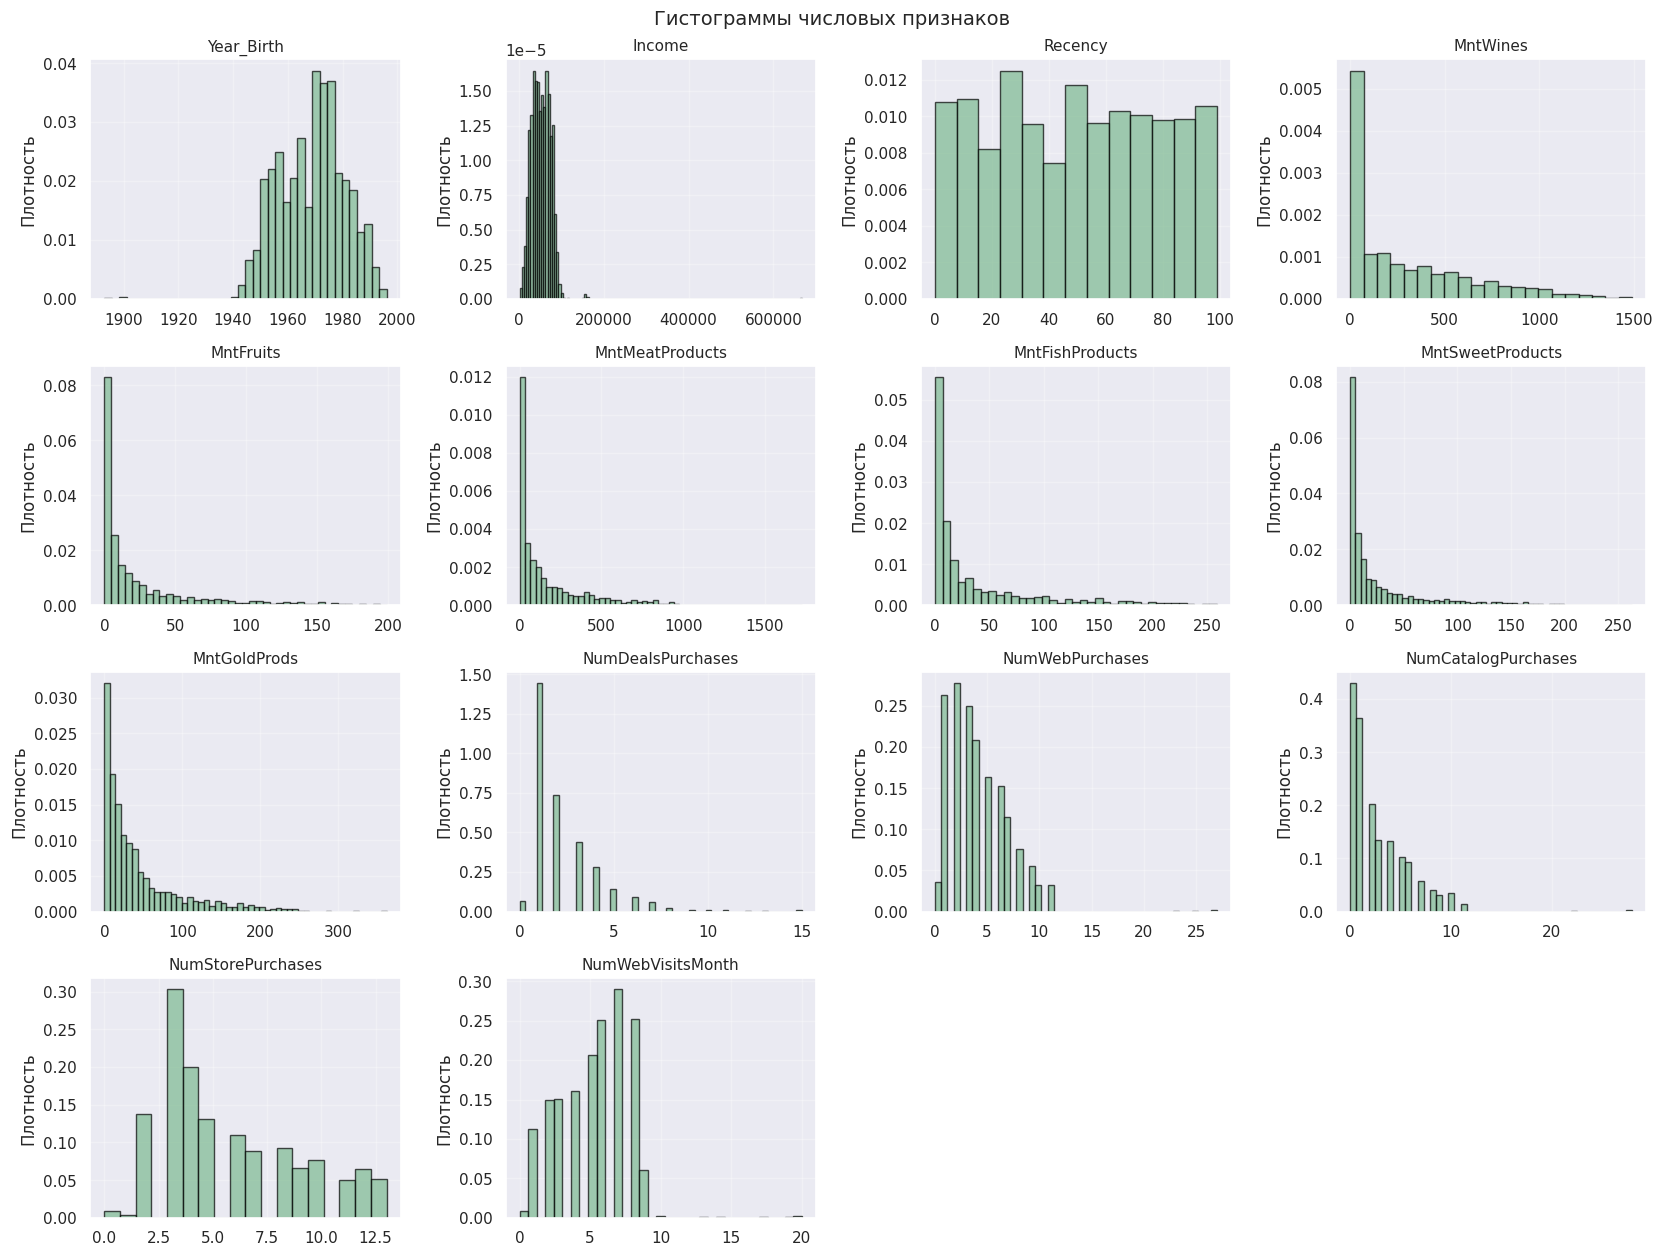

In [6]:
# Гистограммы

sns.set_theme(style="darkgrid", context="notebook", palette="crest")

# Тот же набор числовых столбцов что и KDE
cols = [
    "Year_Birth", "Income", "Recency",
    "MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts",
    "MntSweetProducts", "MntGoldProds",
    "NumDealsPurchases", "NumWebPurchases",
    "NumCatalogPurchases", "NumStorePurchases", "NumWebVisitsMonth"
]

n = len(cols)
ncols = 4
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.2 * nrows))
axes = np.array(axes).ravel()

for idx, col in enumerate(cols):
    ax = axes[idx]
    s = df[col].dropna().astype(float)

    # Гистограмма с нормировкой
    ax.hist(s, bins="auto", density=True, edgecolor="black", alpha=0.7)

    ax.set_title(col, fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("Плотность")
    ax.grid(alpha=0.3)

for idx in range(n, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("Гистограммы числовых признаков", fontsize=14)
plt.tight_layout()
plt.show()


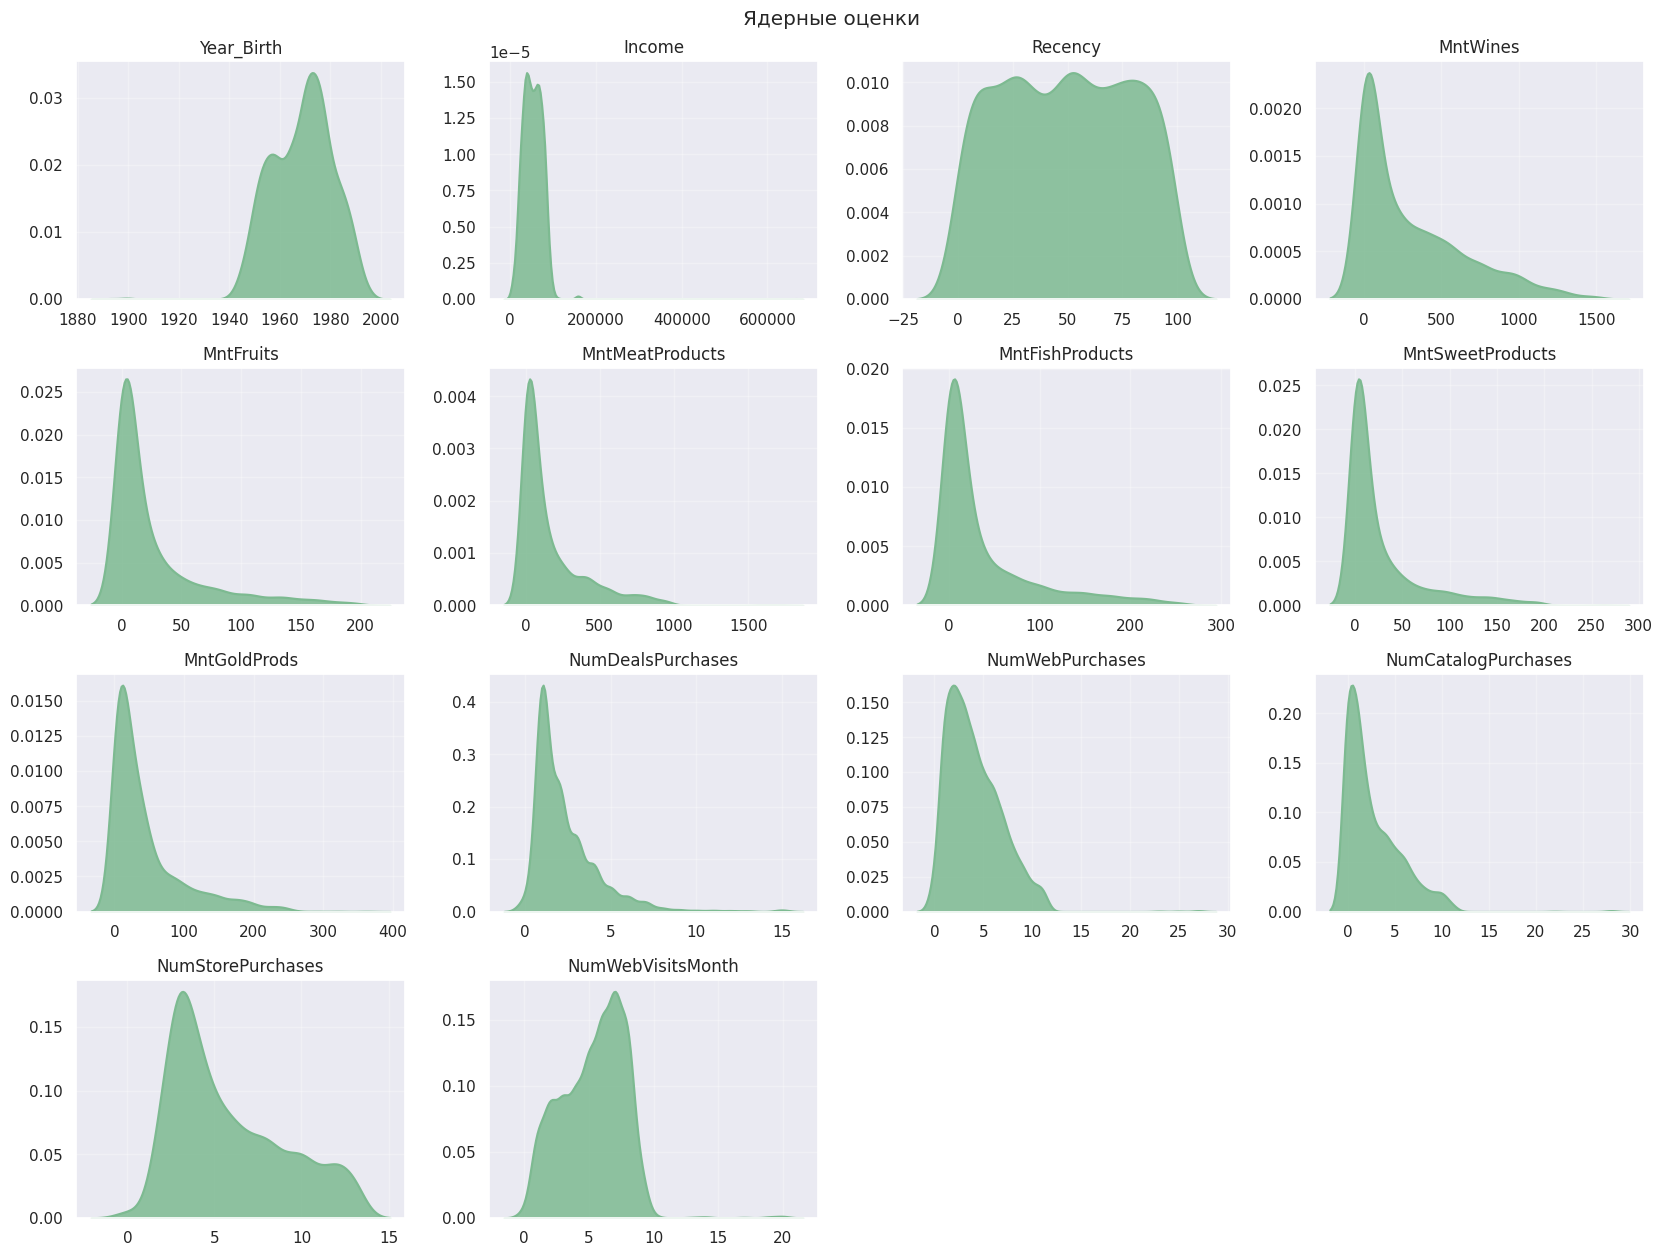

In [ ]:

sns.set_theme(style="darkgrid", context="notebook", palette="crest")

cols = [
    "Year_Birth", "Income", "Recency",
    "MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts",
    "MntSweetProducts", "MntGoldProds",
    "NumDealsPurchases", "NumWebPurchases",
    "NumCatalogPurchases", "NumStorePurchases", "NumWebVisitsMonth"
]

# сетка под все KDE
n = len(cols)
ncols = 4
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2*ncols, 3.2*nrows))
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]
    s = df[col].dropna()
    # KDE
    sns.kdeplot(s, ax=ax, fill=True, linewidth=1.6, alpha=0.85)

    ax.set_title(col, fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.grid(alpha=0.3)


for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Ядерные оценки")
plt.tight_layout()
plt.show()


### 3 Анализ данных с помощью cdplot, dotchart, boxplot и stripchart.

Посмотрим на плотность расходов на вино по образованию(cdplot) `1` , расходы на вино по образованию (dotchart) `2`, на доход по семейному статусу(boxplot) `3` и на кол-во дней с последней покупки по семейному статусу(stripchart) `4`.

In [ ]:
sns.set_theme(style="darkgrid", context="notebook")

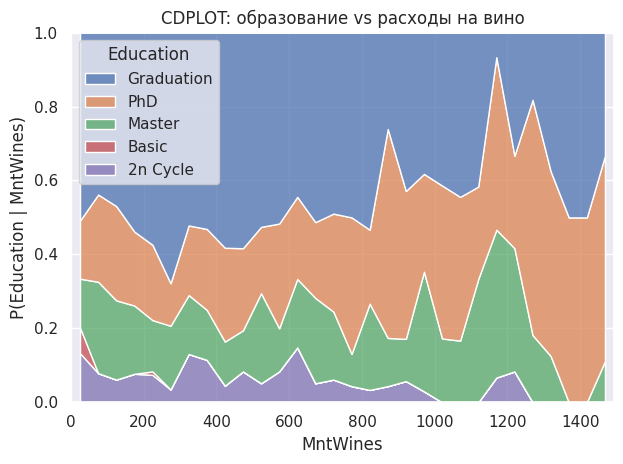

In [ ]:
order_edu = df["Education"].value_counts().index
ax = sns.histplot(data=df, x="MntWines", hue="Education", multiple="fill", bins=30, element="poly")
ax.set_ylabel("P(Education | MntWines)")
ax.set_title("CDPLOT: образование vs расходы на вино")
plt.tight_layout()


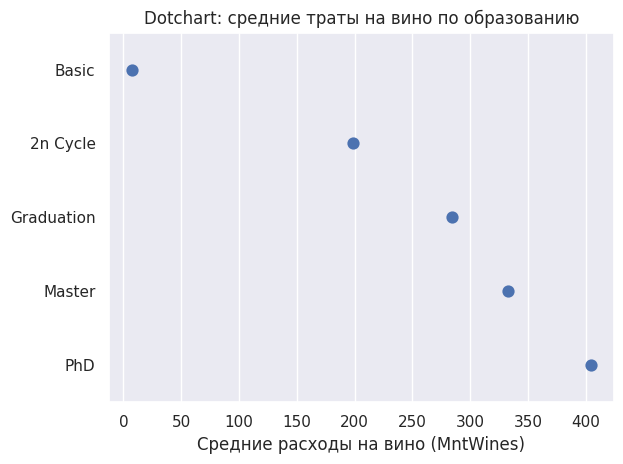

In [ ]:
order_edu_mean = (df.groupby("Education")["MntWines"].mean().sort_values().index)
sns.pointplot(data=df, y="Education", x="MntWines", errorbar=None, linestyle='none', order=order_edu_mean)
plt.title("Dotchart: средние траты на вино по образованию")
plt.xlabel("Средние расходы на вино (MntWines)")
plt.ylabel("")
plt.tight_layout()

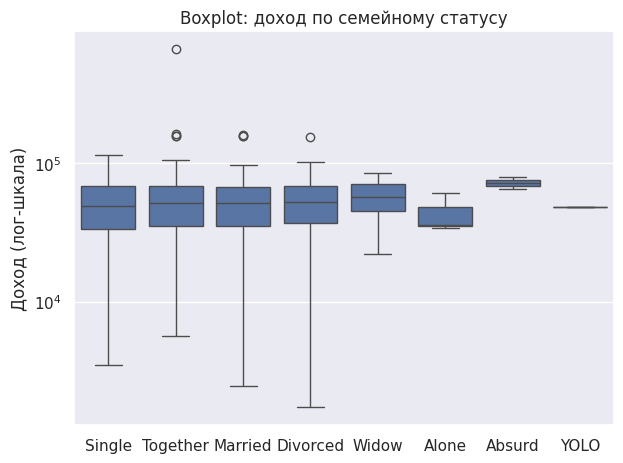

In [ ]:
order_ms = df["Marital_Status"].value_counts().index
ax = sns.boxplot(data=df, x="Marital_Status", y="Income")
ax.set_yscale("log")
ax.set_title("Boxplot: доход по семейному статусу")
ax.set_xlabel("")
ax.set_ylabel("Доход (лог-шкала)")
plt.tight_layout()

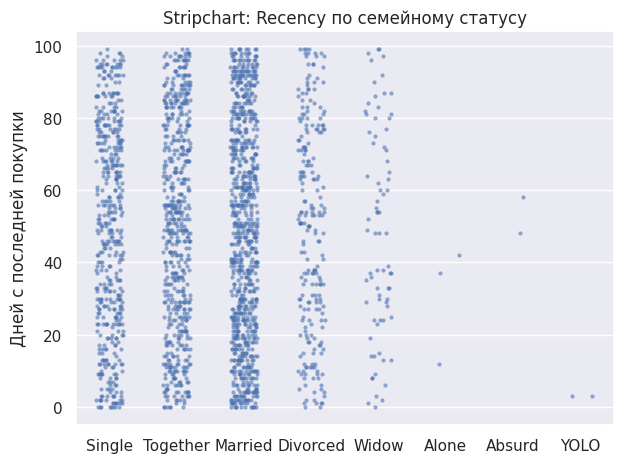

In [ ]:
sns.stripplot(data=df, x="Marital_Status", y="Recency", alpha=0.6, size=3, jitter=0.2)
plt.title("Stripchart: Recency по семейному статусу")
plt.xlabel("")
plt.ylabel("Дней с последней покупки")
plt.tight_layout()

1. У Basic заметна концентрация около низких трат на вино; группы Master, PhD и Graduation смещены вправо и имеют более широкий правый хвост
2. Порядок по средним PhD > Graduation > Master > 2nCycle >> Basic
3. Медианы дохода между статусами близки, но разброс отличается
4. Явных сдвигов между категориями не видно

### 4 Критерии Граббса и Q-тест Диксона.

**Критерий Граббса**

In [8]:
df.groupby('Education')['Income'].apply(lambda s: stats.shapiro(s.dropna().astype(float))[1]).sort_values(ascending=False)

,Income
Education,
Basic,2.059809e-01
2n Cycle,1.607382e-04
Master,2.057815e-05
PhD,1.183073e-12
Graduation,1.877473e-42


Так как наши данные далеки от нормальных, то для того чтобы можно было применить критерий Граббса будем использовать Income | Education = Basic. p_value Шапиро около 0.2

In [9]:
x = df.loc[df['Education']=='Basic', 'Income'].dropna().astype(float).values
stats.shapiro(x)[1]


np.float64(0.20598086530848275)

In [10]:
def grubbs_two_sided(x, alpha=0.05):
    x = np.asarray(x, float)
    n=x.size
    m=x.mean()
    s=x.std(ddof=1)
    z=np.abs(x-m)
    i=z.argmax()
    G=z[i]/s
    t=stats.t.ppf(1-alpha/(2*n), n-2)
    Gcrit=((n-1)/np.sqrt(n))*np.sqrt(t**2/(n-2+t**2))
    return G, Gcrit, (G>Gcrit), i

G, Gcrit, is_out, i = grubbs_two_sided(x)
G, Gcrit, is_out

(np.float64(2.2676165716961245), np.float64(3.1587939408872967), np.False_)

Видим, что выброса нет, поэтому добавим синтетический

In [11]:
if not is_out:
    x_aug = np.append(x, x.mean() + 6*x.std())
    G2, Gcrit2, is_out2, i2 = grubbs_two_sided(x_aug)
    G2, Gcrit2, is_out2
else:
    x_aug = x

In [12]:
G2, Gcrit2, is_out2

(np.float64(4.579762632956622), np.float64(3.165988918336084), np.True_)

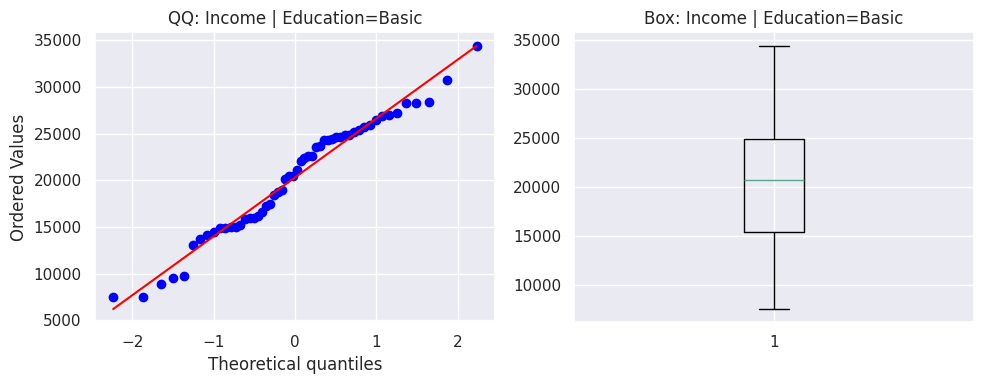

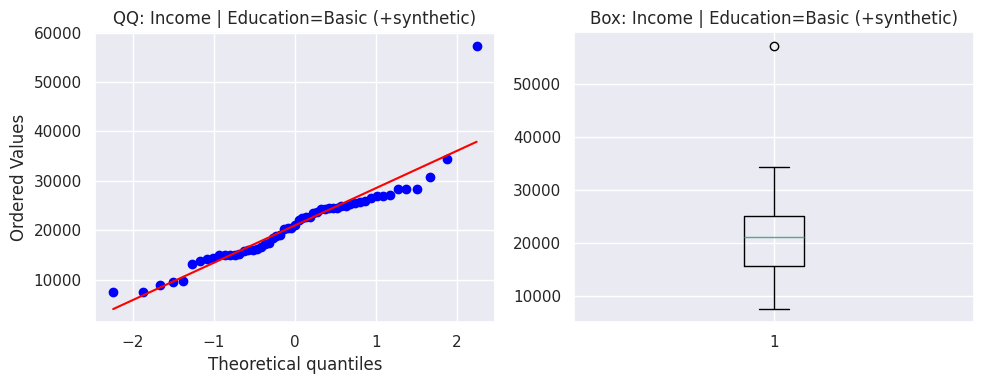

In [13]:
def plots(x, title):
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    stats.probplot(x, dist='norm', plot=plt)
    plt.title(f'QQ: {title}')
    plt.subplot(1,2,2)
    plt.boxplot(x)
    plt.title(f'Box: {title}')
    plt.tight_layout()
    plt.show()

plots(x, 'Income | Education=Basic')
plots(x_aug, 'Income | Education=Basic (+synthetic)' if len(x_aug)>len(x) else 'Income | Education=Basic')


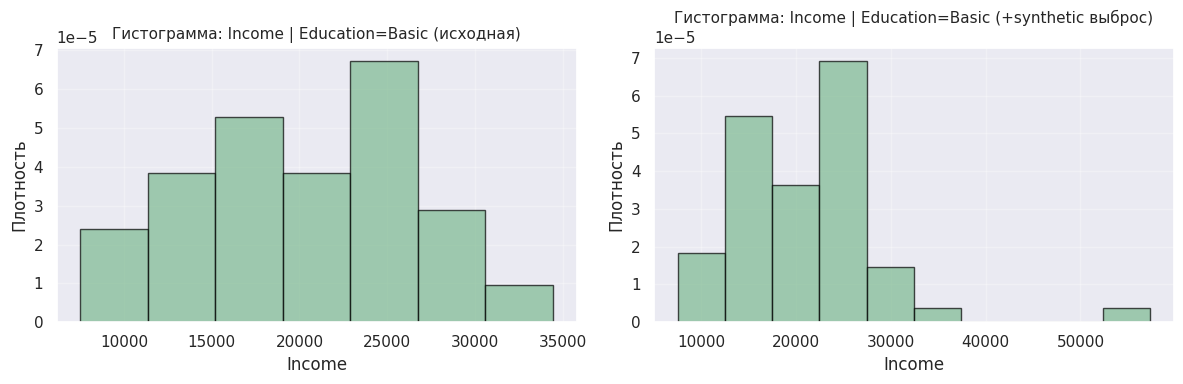

In [14]:
# Гистограммы выборок для критерия Граббса

plt.figure(figsize=(12, 4))

#Исходная подвыборка
plt.subplot(1, 2, 1)
plt.hist(x, bins="auto", density=True, edgecolor="black", alpha=0.7)
plt.title("Гистограмма: Income | Education=Basic (исходная)", fontsize=11)
plt.xlabel("Income")
plt.ylabel("Плотность")
plt.grid(alpha=0.3)

#Та же выборка с синтетическим выбросом
plt.subplot(1, 2, 2)
plt.hist(x_aug, bins="auto", density=True, edgecolor="black", alpha=0.7)
plt.title("Гистограмма: Income | Education=Basic (+synthetic выброс)", fontsize=11)
plt.xlabel("Income")
plt.ylabel("Плотность")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


**Q-тест Диксона**

Снова сделаем выборку, так как Q-тест применим для n<=30

In [15]:
sub = df.loc[df["Education"] == "Basic", "Income"].dropna().astype(float)
x = sub.sample(min(29, len(sub)), random_state=1).values
len(x), x[:5]

(29, array([17256.,  9548., 22123., 13724., 22634.]))

Shapiro p-value = 0.199  (OK для Диксона, если > 0.05)


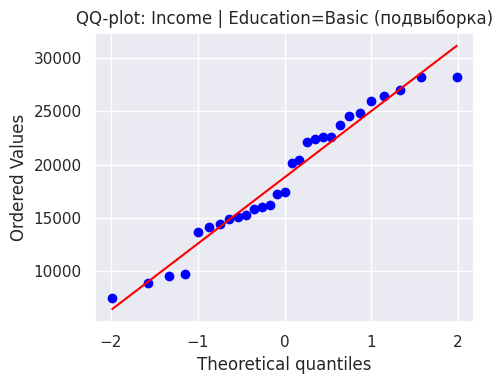

In [16]:
p_shapiro = stats.shapiro(x)[1]
print(f"Shapiro p-value = {p_shapiro:.3f}  (OK для Диксона, если > 0.05)")

plt.figure(figsize=(5,4))
stats.probplot(x, dist="norm", plot=plt)
plt.title("QQ-plot: Income | Education=Basic (подвыборка)")
plt.tight_layout()
plt.show()

In [17]:
DIXON_Q_005 = {
    3:0.941,4:0.765,5:0.642,6:0.560,7:0.507,8:0.468,9:0.437,10:0.412,
    11:0.392,12:0.376,13:0.361,14:0.349,15:0.338,16:0.329,17:0.320,18:0.313,
    19:0.306,20:0.300,21:0.295,22:0.290,23:0.285,24:0.281,25:0.277,26:0.273,
    27:0.270,28:0.267,29:0.263,30:0.260
}

def dixon_test_two_sided(x, alpha=0.05):
    #Возвращаем (is_outlier, side, Q, Qcrit, idx) для двустороннего теста.
    x = np.asarray(x, float)
    n = x.size
    if n < 3 or n > 30 or (x.max() - x.min()) == 0:
        return False, None, np.nan, np.nan, None
    Qcrit = DIXON_Q_005.get(n, np.nan)

    order = np.argsort(x)
    xs = x[order]

    Q_low  = (xs[1]  - xs[0]) / (xs[-1] - xs[0])
    Q_high = (xs[-1] - xs[-2]) / (xs[-1] - xs[0])

    if Q_low >= Q_high:
        Q, side, idx_sorted = Q_low, "low", 0
    else:
        Q, side, idx_sorted = Q_high, "high", -1

    is_out = Q > Qcrit
    idx_original = order[idx_sorted]
    return is_out, side, Q, Qcrit, idx_original

is_out, side, Q, Qcrit, idx0 = dixon_test_two_sided(x)
print(f"Q={Q:.3f}, Qcrit={Qcrit:.3f}. Выброс найден: {is_out} (side={side})")

Q=0.069, Qcrit=0.263. Выброс найден: False (side=low)


Выбросов на нашей группе снова нет, поэтому синтезируем, чтобы проверить тест

In [18]:
if not is_out:
    x_aug = np.append(x, x.mean() + 6*x.std(ddof=1))   # «явный» верхний выброс
    is_out2, side2, Q2, Qcrit2, idx2 = dixon_test_two_sided(x_aug, alpha=0.05)
    print(f"[+synthetic] Q={Q2:.3f}, Qcrit={Qcrit2:.3f}. Выброс найден: {is_out2} (side={side2})")
else:
    x_aug = x


[+synthetic] Q=0.566, Qcrit=0.260. Выброс найден: True (side=high)


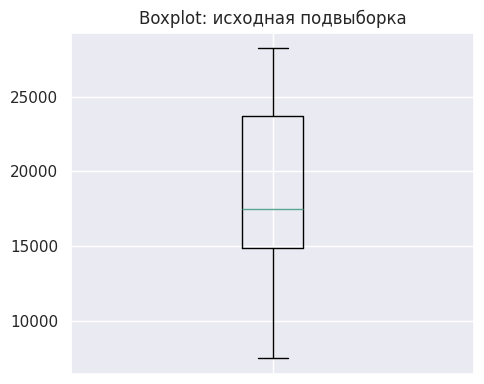

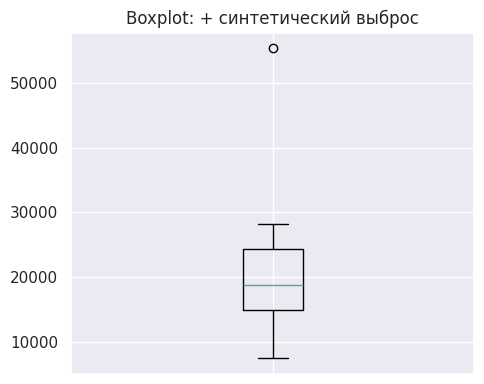

In [19]:
def show_box_with_mark(x, title=""):
    plt.figure(figsize=(5,4))
    plt.boxplot(x)
    plt.title(title)
    plt.xticks([1], [""])
    plt.tight_layout()
    plt.show()

show_box_with_mark(x, "Boxplot: исходная подвыборка")

show_box_with_mark(x_aug, "Boxplot: + синтетический выброс")

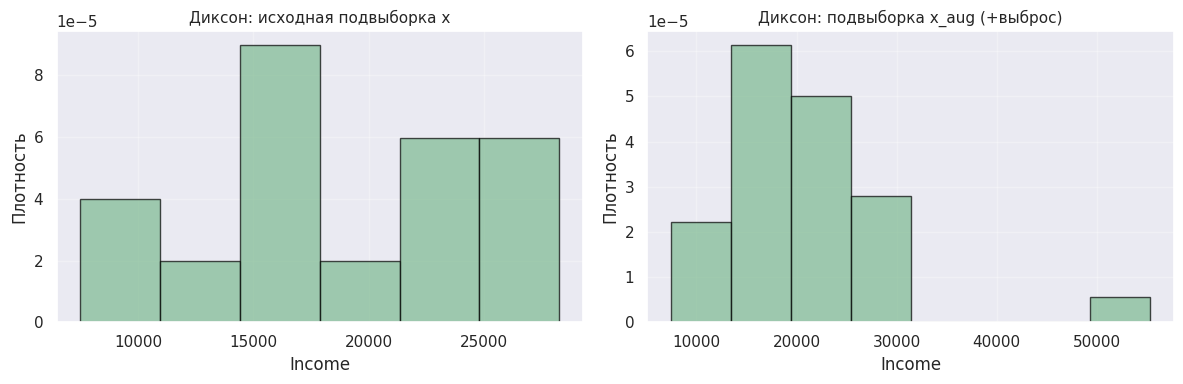

In [20]:
# Гистограммы выборок для Q-теста Диксона

plt.figure(figsize=(12, 4))

#Исходная подвыборка
plt.subplot(1, 2, 1)
plt.hist(x, bins="auto", density=True, edgecolor="black", alpha=0.7)
plt.title("Диксон: исходная подвыборка x", fontsize=11)
plt.xlabel("Income")
plt.ylabel("Плотность")
plt.grid(alpha=0.3)

#Подвыборка с синтетическим выбросом
plt.subplot(1, 2, 2)
plt.hist(x_aug, bins="auto", density=True, edgecolor="black", alpha=0.7)
plt.title("Диксон: подвыборка x_aug (+выброс)", fontsize=11)
plt.xlabel("Income")
plt.ylabel("Плотность")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### 5 Заполнение пропусков.

Для начала создадим пропуски

Сделаем около 10% пропусков в столбцах "Income", "MntWines", "Recency"

In [ ]:
num_cols = ["Income", "MntWines", "Recency"]

true_num = df[num_cols].copy()
miss_num = true_num.copy()

rng = np.random.default_rng(42)
p_num = 0.1

miss_mask = {}
for c in num_cols:
    mask = rng.random(len(miss_num)) < p_num
    miss_num.loc[mask, c] = np.nan
    miss_mask[c] = mask

miss_num.head()

,Income,MntWines,Recency
0,58138.0,635.0,58.0
1,46344.0,NaN,38.0
2,71613.0,426.0,26.0
3,26646.0,11.0,26.0
4,NaN,173.0,94.0


Теперь будем импутировать пропуски через среднию, медиану, KNN и Iterative

In [ ]:
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler

# mean/median
imp_mean   = SimpleImputer(strategy="mean")
imp_median = SimpleImputer(strategy="median")
num_mean   = pd.DataFrame(imp_mean.fit_transform(miss_num),   columns=num_cols, index=miss_num.index)
num_median = pd.DataFrame(imp_median.fit_transform(miss_num), columns=num_cols, index=miss_num.index)

# KNN (скейлинг KNN обратный скейлинг)
scaler = StandardScaler()
miss_scaled = pd.DataFrame(scaler.fit_transform(miss_num), columns=num_cols, index=miss_num.index)
knn = KNNImputer(n_neighbors=5, weights="distance")
num_knn_scaled = pd.DataFrame(knn.fit_transform(miss_scaled), columns=num_cols, index=miss_num.index)
num_knn = pd.DataFrame(scaler.inverse_transform(num_knn_scaled), columns=num_cols, index=miss_num.index)

# Iterative
it = IterativeImputer(random_state=42, max_iter=20)
num_iter = pd.DataFrame(it.fit_transform(miss_num), columns=num_cols, index=miss_num.index)

recon = {
    "mean":   num_mean,
    "median": num_median,
    "knn":    num_knn,
    "iter":   num_iter,
}


Оценим работу

In [ ]:
from sklearn.metrics import mean_absolute_error
def eval_num(true_df: pd.DataFrame, recon_dict: dict[str, pd.DataFrame], mask_dict: dict[str, np.ndarray]) -> pd.DataFrame:
    rows = []

    for name, xhat in recon_dict.items():
        maes, rmses = [], []

        for c in true_df.columns:
            m = mask_dict[c]
            if not np.any(m):
                continue

            y_true = true_df.loc[m, c].to_numpy()
            y_pred = xhat.loc[m, c].to_numpy()

            ok = ~np.isnan(y_true) & ~np.isnan(y_pred)
            if not np.any(ok):
                continue

            mae  = mean_absolute_error(y_true[ok], y_pred[ok])
            rmse = float(np.sqrt(np.mean((y_true[ok] - y_pred[ok])**2)))

            maes.append(mae)
            rmses.append(rmse)

        num_mae  = float(np.mean(maes))
        num_rmse = float(np.mean(rmses))

        rows.append({"method": name, "NUM_MAE": num_mae, "NUM_RMSE": num_rmse})

    return pd.DataFrame(rows).sort_values(["NUM_MAE", "NUM_RMSE"])

# запуск
score_table = eval_num(true_num, recon, miss_mask)
score_table

,method,NUM_MAE,NUM_RMSE
3,iter,4431.235799,5986.116704
0,mean,6431.943561,7511.378902
1,median,6444.046136,7535.856099
2,knn,7310.231205,13086.976969


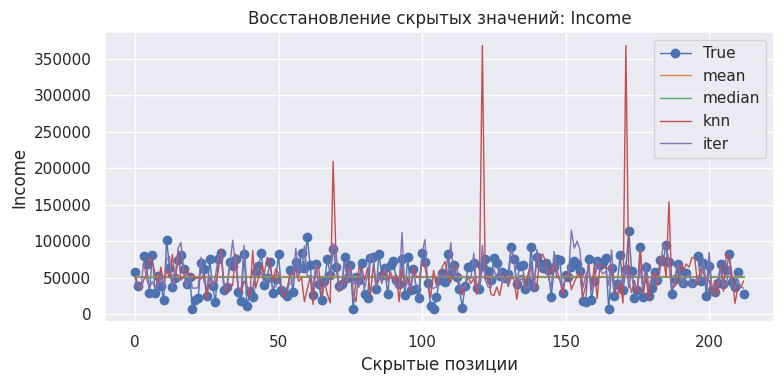

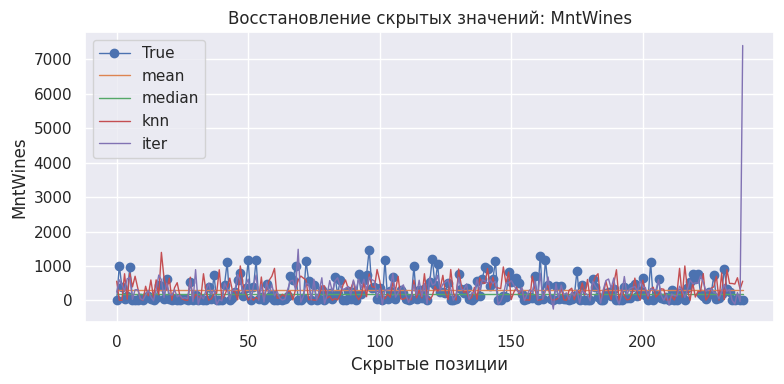

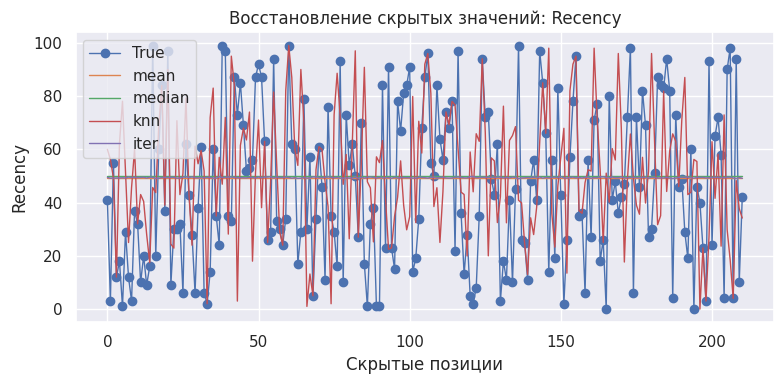

In [ ]:
for col in num_cols:
  mask = miss_mask[col]
  y_true = true_num.loc[mask, col].values

  plt.figure(figsize=(8,4))
  plt.plot(y_true, marker="o", linewidth=1, label="True")
  for name, xhat in recon.items():
      plt.plot(xhat.loc[mask, col].values, linewidth=1, label=name)
  plt.title(f"Восстановление скрытых значений: {col}")
  plt.xlabel("Скрытые позиции")
  plt.ylabel(col)
  plt.legend()
  plt.tight_layout()
  plt.show()


### 6 Нормальные распределения.

Сгенерируем данные

In [ ]:
rng = np.random.default_rng(42)

def gen_normal(n, mu=0.0, sigma=1.0):
    return rng.normal(mu, sigma, size=n)

n_small = 50
n_mod   = 2000

params = [(0, 1), (10, 2)]

samples = {f"small_mu{mu}_sd{sd}": gen_normal(n_small, mu, sd) for (mu, sd) in params}
samples.update({f"mod_mu{mu}_sd{sd}": gen_normal(n_mod, mu, sd) for (mu, sd) in params})

Эмпирическая CDF, QQ и огибающие

In [ ]:
import statsmodels.api as sm
from statsmodels.distributions.empirical_distribution import ECDF

# эмпирическая CDF
def plot_edf(x, title=""):
    x = np.asarray(x, float)
    ecdf = ECDF(x)
    mu, sd = x.mean(), x.std(ddof=1)

    xs = np.linspace(x.min(), x.max(), 300)
    plt.figure(figsize=(6,4))
    plt.plot(xs, ecdf(xs), drawstyle="steps-post", label="EDF")
    plt.plot(xs, stats.norm.cdf(xs, loc=mu, scale=sd), "--", label=f"CDF({mu:.2f},{sd:.2f})")
    plt.title(f"EDF vs normal  |  {title}")
    plt.legend()
    plt.tight_layout()
    plt.show()

#QQ-plot с огибающими
def qq_with_envelope(x, B=200, alpha=0.05, title=""):
    x = np.asarray(x, float)
    n = x.size
    mu, sd = x.mean(), x.std(ddof=1)

    probs   = (np.arange(1, n+1) - 0.5) / n
    q_theor = stats.norm.ppf(probs)
    q_samp  = np.sort((x - mu) / sd)

    Z = np.random.normal(size=(B, n))
    Z = (Z - Z.mean(axis=1, keepdims=True)) / Z.std(axis=1, ddof=1, keepdims=True)
    Z.sort(axis=1)
    lower = np.quantile(Z, alpha/2, axis=0)
    upper = np.quantile(Z, 1 - alpha/2, axis=0)

    sm.qqplot((x - mu)/sd, line="45", fit=False)
    plt.plot(q_theor, lower, "--", label=f"{int((1-alpha)*100)}% envelope")
    plt.plot(q_theor, upper, "--")
    plt.title(f"QQ + envelope  |  {title}")
    plt.tight_layout(); plt.legend(); plt.show()

Тесты на нормальность

In [ ]:
from statsmodels.stats.diagnostic import lilliefors
from sfrancia import shapiroFrancia

def run_normality_tests(x: np.ndarray) -> dict:
    #Возвращает словарь с результатами стандартных тестов на нормальность:
    x = np.asarray(x, float)
    x = x[~np.isnan(x)]
    n = x.size

    mu = x.mean()
    sd = x.std(ddof=1)

    # Шапиро-Уилк
    _, sw_p = stats.shapiro(x)

    # Андерсон-Дарлинг
    ad_res = stats.anderson(x, dist="norm")
    ad_stat = ad_res.statistic

    # Крамер фон Мизес
    cvm_p = stats.cramervonmises(x, "norm").pvalue

    # Колмогоров-Смирнов с (μ,σ)
    ks_p = stats.kstest(x, "norm", args=(mu, sd)).pvalue

    # Лиллиефорс
    lf_stat, lf_p = lilliefors(x, dist="norm")

    # Шапиро-Франс
    sf_res = shapiroFrancia(x)
    sf_w = float(sf_res['statistics W'])
    sf_p = float(sf_res['p-value'])

    return {
        "n": n,
        "Shapiro-Wilk_p": sw_p,
        "Anderson_stat": ad_stat,
        "CvM_p": cvm_p,
        "KS_p (fitted μ,σ)": ks_p,
        "Lilliefors_p": lf_p,
        "Shapiro-Francia_W'": sf_w,
        "Shapiro-Francia_p": sf_p,
    }


Демонстрация для сгенерированных

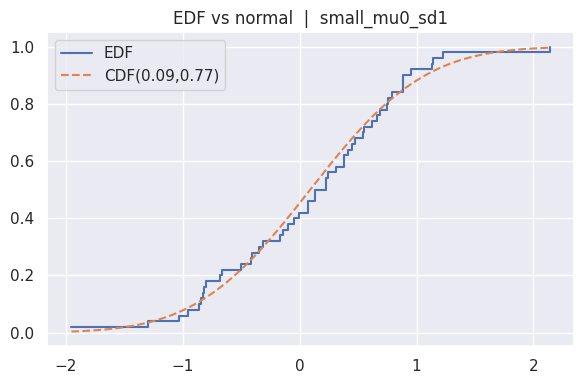

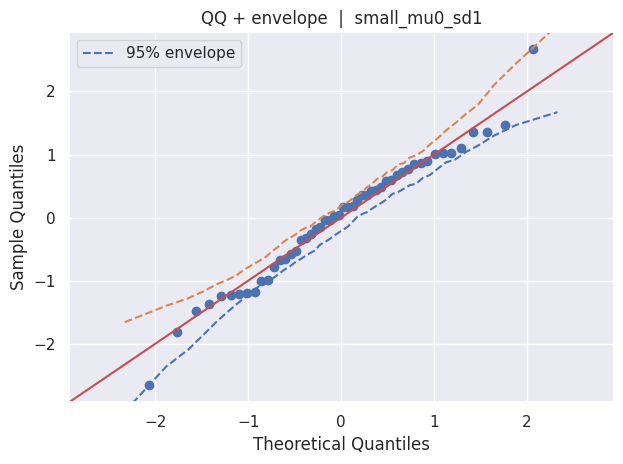

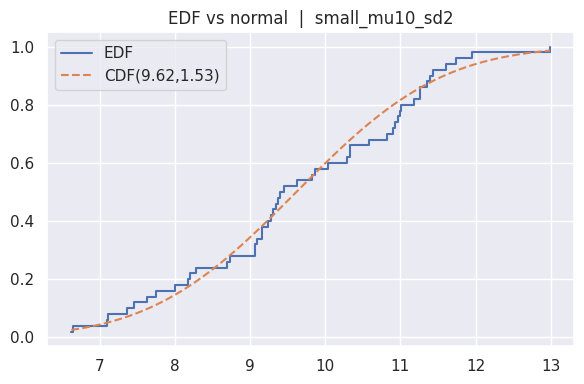

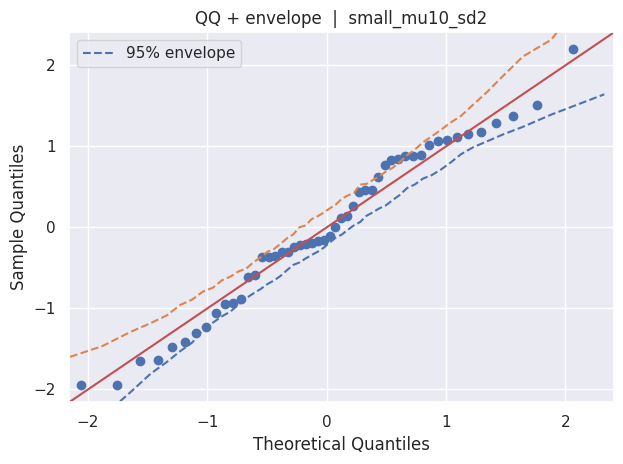

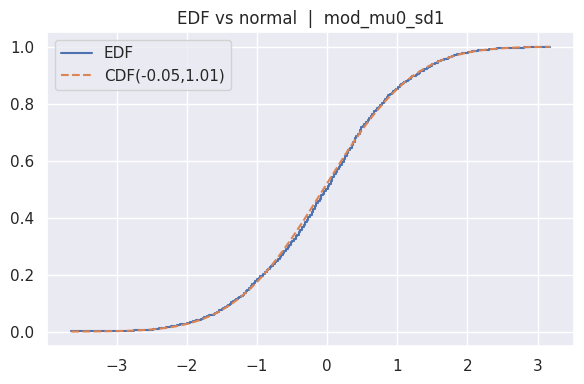

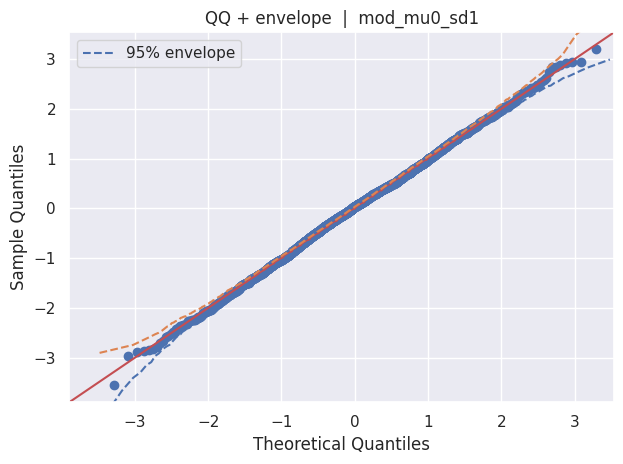

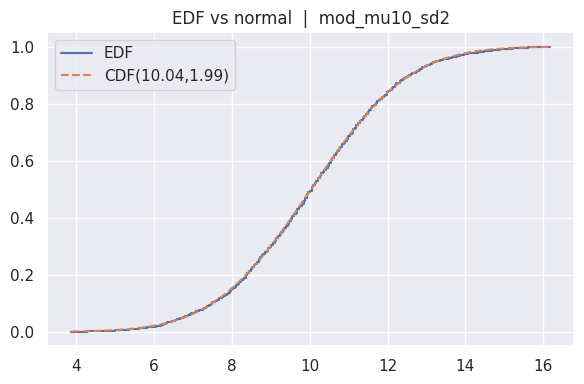

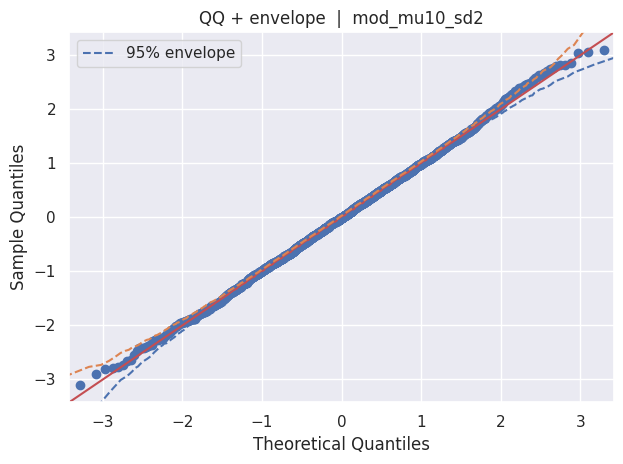

,n,Shapiro-Wilk_p,Anderson_stat,CvM_p,"KS_p (fitted μ,σ)",Lilliefors_p,Shapiro-Francia_W',Shapiro-Francia_p
sample,,,,,,,,
small_mu0_sd1,50,0.730143,0.315974,2.510319e-01,0.967516,0.826521,0.978769,0.424360
small_mu10_sd2,50,0.298969,0.472274,5.220812e-10,0.664317,0.240207,0.977837,0.392810
mod_mu0_sd1,2000,0.483582,0.659698,4.886963e-02,0.529971,0.134230,0.999227,0.528507
mod_mu10_sd2,2000,0.402085,0.180388,1.918155e-07,0.998247,0.977543,0.999275,0.589075


In [ ]:
results = []
for name, x in samples.items():

    plot_edf(x, title=name)
    qq_with_envelope(x, B=200, alpha=0.05, title=name)

    res = run_normality_tests(x)
    res["sample"] = name
    res["n"] = len(x)
    results.append(res)

pd.DataFrame(results).set_index("sample")


### 7 Анализ данных с помощью графиков квантилей, метода огибающих и стандартных процедур проверки гипотез о нормальности.

Делаем выборки

In [ ]:
col = "Income"

# Малая
small = df.loc[df["Education"] == "Basic", col].dropna().astype(float)
small = small.sample(min(len(small), 50), random_state=7).values

# Умеренная
moderate = df[col].dropna().astype(float)
moderate = moderate.sample(min(len(moderate), 2000), random_state=7).values

len(small), len(moderate)


(50, 2000)

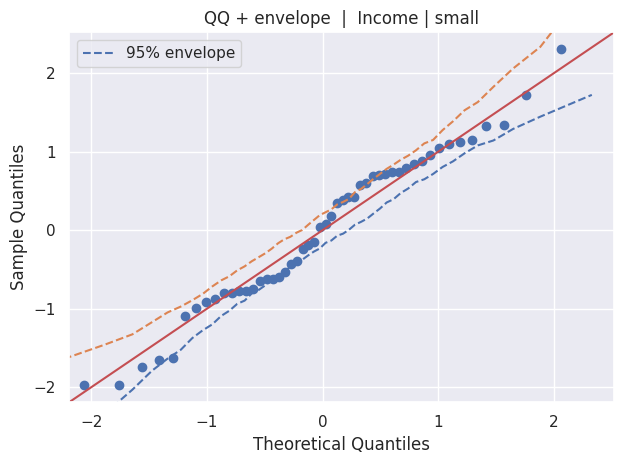

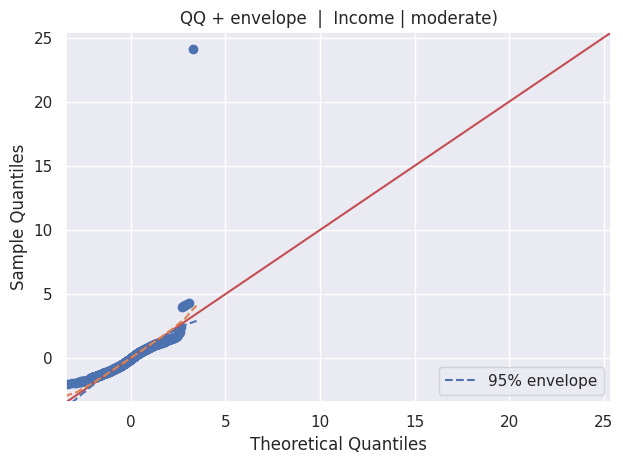

In [ ]:
qq_with_envelope(small, B=300, alpha=0.05, title=f"{col} | small")
qq_with_envelope(moderate, B=200, alpha=0.05, title=f"{col} | moderate)")


In [ ]:
res_small    = run_normality_tests(small)
res_small["sample"] = "small"
res_moderate = run_normality_tests(moderate)
res_moderate["sample"] = "moderate"

pd.DataFrame([res_small, res_moderate]).set_index("sample")


,n,Shapiro-Wilk_p,Anderson_stat,CvM_p,"KS_p (fitted μ,σ)",Lilliefors_p,Shapiro-Francia_W',Shapiro-Francia_p
sample,,,,,,,,
small,50,3.158906e-01,0.545057,5.220809e-10,0.716342,0.306525,0.977009,3.664418e-01
moderate,2000,4.226573e-47,16.309142,0.000000e+00,0.000004,0.001000,0.757033,5.320385e-43


Малая выборка: SW, AD, KS, Lilliefors и Shapiro–Francia не отвергают нормальность (p > 0.05).

Умеренная выборка: все критерии (SW, AD, CvM, KS, Lilliefors, SF) отвергают нормальность на уровне 0.05, тк тесты становятся очень чувствительными. Небольшие отклонения формы/хвостов становятся статистически значимыми.

## Второй этап

In [ ]:
df = pd.read_csv('data.csv')
from scipy import stats

###1 Проверка гипотез.

**Стьюдент**

In [ ]:
data = df[["Income", "Response"]].dropna()
group0 = data.loc[data["Response"] == 0, "Income"].values
group1 = data.loc[data["Response"] == 1, "Income"].values
print(f"Размер группы Response=0: {len(group0)}")
print(f"Размер группы Response=1: {len(group1)}")

Размер группы Response=0: 1883
Размер группы Response=1: 333


Проверим применимость:

In [ ]:
# Проверка на нормальность
shapiro0 = stats.shapiro(group0[:500])
shapiro1 = stats.shapiro(group1[:500])

print("Проверка нормальности (Шапиро–Уилка):")
print("Response=0:", shapiro0)
print("Response=1:", shapiro1)

# Проверка равенства дисперсий
levene_res = stats.levene(group0, group1)
print("Проверка равенства дисперсий (Левен):", levene_res)

equal_var = levene_res.pvalue > 0.05
print("Считать дисперсии равными?", equal_var)

Проверка нормальности (Шапиро–Уилка):
Response=0: ShapiroResult(statistic=np.float64(0.9765459576525591), pvalue=np.float64(3.429889853465134e-07))
Response=1: ShapiroResult(statistic=np.float64(0.95672100004323), pvalue=np.float64(2.3915645002126436e-08))
Проверка равенства дисперсий (Левен): LeveneResult(statistic=np.float64(6.2857207147104495), pvalue=np.float64(0.012242564103551385))
Считать дисперсии равными? False


При таких данных нельзя использовать тест Стьюдента, преобразуем данные:

In [ ]:
# лог-преобразование дохода
data["LogIncome"] = np.log(data["Income"] + 1)

# обрезаем
low, high = np.percentile(data["LogIncome"], [1, 99])
data_pre = data[(data["LogIncome"] >= low) & (data["LogIncome"] <= high)]

g0 = data_pre.loc[data_pre["Response"] == 0, "LogIncome"].values
g1 = data_pre.loc[data_pre["Response"] == 1, "LogIncome"].values

print("Размер группы Response=0:", len(g0))
print("Размер группы Response=1:", len(g1))

Размер группы Response=0: 1849
Размер группы Response=1: 321


In [ ]:
#проверка на нормальность
shapiro0 = stats.shapiro(g0[:500])
shapiro1 = stats.shapiro(g1[:500])
print("Response=0:", shapiro0)
print("Response=1:", shapiro1)

# равенство дисперсий
levene_res = stats.levene(g0, g1)
print("Левен:", levene_res)

equal_var = levene_res.pvalue > 0.05
print("Считать дисперсии равными?", equal_var)

Response=0: ShapiroResult(statistic=np.float64(0.9520995109343922), pvalue=np.float64(1.1798456882448795e-11))
Response=1: ShapiroResult(statistic=np.float64(0.8992150808790829), pvalue=np.float64(8.957251383541425e-14))
Левен: LeveneResult(statistic=np.float64(0.35647002960743035), pvalue=np.float64(0.5505356018155365))
Считать дисперсии равными? True


Тест Шапиро-Уилка не проходит из-за сликшом большего объема выборки, посмотрим на графики

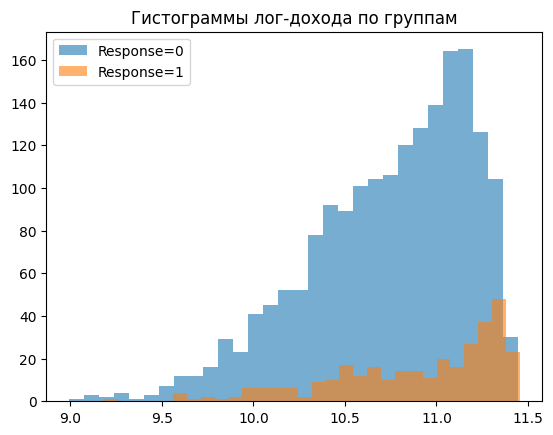

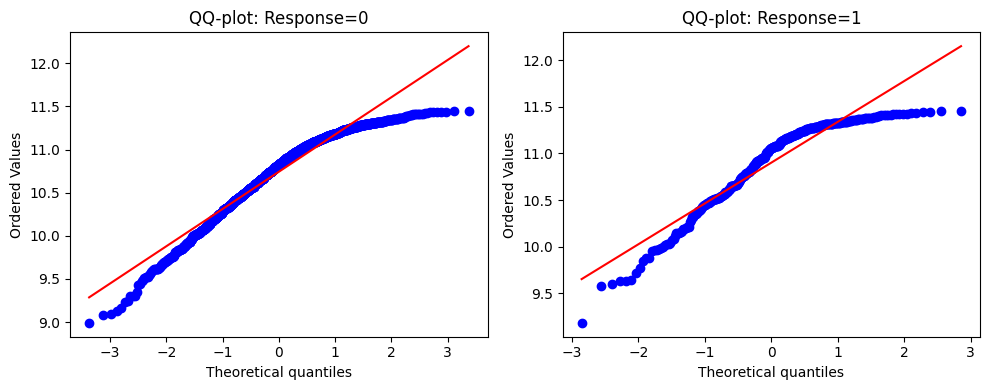

In [ ]:
plt.figure()
plt.hist(g0, bins=30, alpha=0.6, label="Response=0")
plt.hist(g1, bins=30, alpha=0.6, label="Response=1")
plt.title("Гистограммы лог-дохода по группам")
plt.legend()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
stats.probplot(g0, dist="norm", plot=axes[0])
axes[0].set_title("QQ-plot: Response=0")
stats.probplot(g1, dist="norm", plot=axes[1])
axes[1].set_title("QQ-plot: Response=1")
plt.tight_layout()
plt.show()

После логарифмирования дохода и отсечения крайних 1% значений распределения в обеих группах стали близкими к нормальным. По гистограммам и QQ-графикам сильных отклонений в центральной части не видно, отклонения в хвостах носят одинаковый характер. Тест Левена не выявил различий дисперсий, поэтому далее применяем Стьюдента.

Сравним доход (Income) по отклику на компанию (Response)

Двусторонний тест:
*   H0: μ1 = μ2   (средние доходы одинаковы)
*   H1: μ1 ≠ μ2   (средние доходы различаются)

Односторонние тесты:
*   H0: μ1 = μ2
*   H1: μ1 > μ2
*   H1: μ1 < μ2


   

In [ ]:
ttest_res = stats.ttest_ind(g0, g1, equal_var=equal_var)
print("Стьюдента (двусторонний)")
print("t-статистика:", ttest_res.statistic)
print("p-value:", ttest_res.pvalue)

# Односторонние p-value считаем из двустороннего:
t_stat = ttest_res.statistic
p_two = ttest_res.pvalue

# H1: mu_1 > mu_0
if t_stat > 0:
    p_one_greater = p_two / 2
else:
    p_one_greater = 1 - p_two / 2

# H1: mu_1 < mu_0
if t_stat < 0:
    p_one_less = p_two / 2
else:
    p_one_less = 1 - p_two / 2

print("Односторонние варианты")
print("H1: mean(Response=1) > mean(Response=0): p =", p_one_greater)
print("H1: mean(Response=1) < mean(Response=0): p =", p_one_less)

Стьюдента (двусторонний)
t-статистика: -5.896654288755827
p-value: 4.291721788302204e-09
Односторонние варианты
H1: mean(Response=1) > mean(Response=0): p = 0.9999999978541391
H1: mean(Response=1) < mean(Response=0): p = 2.145860894151102e-09


In [ ]:
from statsmodels.stats.weightstats import DescrStatsW, CompareMeans

d0 = DescrStatsW(g0)
d1 = DescrStatsW(g1)

cm = CompareMeans(d1, d0)  # разность: (Response=1) - (Response=0)

print("Доверительные интервалы для разности средних:")
for conf in [0.90, 0.95, 0.99]:
    ci_low, ci_up = cm.tconfint_diff(alpha=1-conf, usevar='pooled')
    mean_diff = d1.mean - d0.mean
    print(f"{conf} ДИ: [{ci_low:.4f}; {ci_up:.4f}], diff={mean_diff:.4f}")

Доверительные интервалы для разности средних:
0.9 ДИ: [0.1145; 0.2031], diff=0.1588
0.95 ДИ: [0.1060; 0.2116], diff=0.1588
0.99 ДИ: [0.0894; 0.2282], diff=0.1588


Мощность:

In [ ]:
from statsmodels.stats.power import TTestIndPower
mean0 = g0.mean()
mean1 = g1.mean()

std_pooled = np.sqrt(((len(g0)-1)*g0.var(ddof=1) + (len(g1)-1)*g1.var(ddof=1)) / (len(g0)+len(g1)-2))
effect_size = (mean1 - mean0) / std_pooled
print("Оценка размера эффекта:", round(effect_size, 3))
analysis = TTestIndPower()

power = analysis.power(effect_size=effect_size,
                        nobs1=len(g1),
                        ratio=len(g0)/len(g1),
                        alpha=0.05,
                        alternative='two-sided')
print("Мощность при текущем объёме выборки:", round(power, 3))

n_req = analysis.solve_power(effect_size=effect_size,
                              power=0.8,
                              alpha=0.05,
                              ratio=1.0,
                              alternative='two-sided')
print("Требуемое n на группу для мощности 0.8:", np.ceil(n_req))

Оценка размера эффекта: 0.357
Мощность при текущем объёме выборки: 1.0
Требуемое n на группу для мощности 0.8: 125.0


Разница между группами умеренной силы(Коэффициент d Коэна), тест очень сильный(при уровне значимости 0,05), при размере выборки 125 тест имел бы мощность 0,8.

**Уилкоксон-Манна-Уитни(ранговый)**

Этот тест можно использовать при независимых наблюдениях, порядковой или количественной шкалой и желательно одинаковой форме распредлений. Можно использовать при ненормальных данных и выбросах.

Проверим те же гипотезы, но на исходной выборке(без обрезания и лог преобразования)

In [ ]:
data = df[["Income", "Response"]].dropna()
group0 = data.loc[data["Response"] == 0, "Income"].values
group1 = data.loc[data["Response"] == 1, "Income"].values

print(f"Размер группы Response=0: {len(group0)}")
print(f"Размер группы Response=1: {len(group1)}")

Размер группы Response=0: 1883
Размер группы Response=1: 333


 Двусторонний:

*   H0: распределения дохода в группах одинаковы
*   H1: распределения дохода различаются




In [ ]:
from scipy.stats import mannwhitneyu
mw_two = mannwhitneyu(group0, group1, alternative="two-sided")
p_two = mw_two.pvalue
print("Уилкоксона-Манна-Уитни (двусторонний):")
print("U =", mw_two.statistic, "p =", p_two)

alphas = [0.1, 0.05, 0.01]
for alpha in alphas:
    if p_two < alpha:
        print(f"При α={alpha} (ДУ {1-alpha:.2f}) H0 отвергается.")
    else:
        print(f"При α={alpha} (ДУ {1-alpha:.2f}) H0 НЕ отвергается.")


Уилкоксона-Манна-Уитни (двусторонний):
U = 231913.5 p = 3.4044165644385486e-14
При α=0.1 (ДУ 0.90) H0 отвергается.
При α=0.05 (ДУ 0.95) H0 отвергается.
При α=0.01 (ДУ 0.99) H0 отвергается.


Односторонние:
* H0: μ1 = μ2
* H1: μ1 > μ2
* H1: μ1 < μ2

In [ ]:
#доход откликнувшихся больше
mw_greater = mannwhitneyu(group0, group1, alternative="less")
p_greater = mw_greater.pvalue
print("Уилкоксона-Манна-Уитни H1 (Response=1) > (Response=0)")
print("U =", mw_greater.statistic, "p =", p_greater)
for alpha in alphas:
    if p_greater < alpha:
        print(f"При α={alpha} (ДУ {1-alpha:.2f}) H0 отвергается.")
    else:
        print(f"При α={alpha} (ДУ {1-alpha:.2f}) H0 НЕ отвергается.")

#доход откликнувшихся меньше
mw_less = mannwhitneyu(group0, group1, alternative="greater")
p_less = mw_less.pvalue
print("\nУилкоксона-Манна-Уитни H1 (Response=1) < (Response=0)")
print("U =", mw_less.statistic, "p =", p_less)
for alpha in alphas:
    if p_less < alpha:
        print(f"При α={alpha} (ДУ {1-alpha:.2f}) H0 отвергается.")
    else:
        print(f"При α={alpha} (ДУ {1-alpha:.2f}) H0 НЕ отвергается.")

Уилкоксона-Манна-Уитни H1 (Response=1) > (Response=0)
U = 231913.5 p = 1.7022082822192743e-14
При α=0.1 (ДУ 0.90) H0 отвергается.
При α=0.05 (ДУ 0.95) H0 отвергается.
При α=0.01 (ДУ 0.99) H0 отвергается.

Уилкоксона-Манна-Уитни H1 (Response=1) < (Response=0)
U = 231913.5 p = 0.999999999999983
При α=0.1 (ДУ 0.90) H0 НЕ отвергается.
При α=0.05 (ДУ 0.95) H0 НЕ отвергается.
При α=0.01 (ДУ 0.99) H0 НЕ отвергается.


**Фишер, Левен, Бартлетт, Флигнер-Килин**

In [ ]:
raw_data = df[["Income", "Response", "Marital_Status"]].dropna()
alphas = [0.1, 0.05, 0.01]

Тест Фишера и Бартлетта чувствительны к выбросам и требуют нормальность данных. Тесты Левена и Флигнера-Килина не требует нормальность(но тест Левена чувствителен к выбросам). Подготовим данные для проверки гипотез.

In [ ]:
prep = raw_data.copy()
prep["LogIncome"] = np.log(prep["Income"] + 1)
low_log, high_log = np.percentile(prep["LogIncome"], [1, 99])
prep = prep[(prep["LogIncome"] >= low_log) & (prep["LogIncome"] <= high_log)]

#группы по Response для Фишера
g0_prep = prep.loc[prep["Response"] == 0, "LogIncome"].values
g1_prep = prep.loc[prep["Response"] == 1, "LogIncome"].values

print("Подготовленные данные (Фишер и Бартлетт):", len(g0_prep), len(g1_prep))

Подготовленные данные (Фишер и Бартлетт): 1849 321


Фишер:

* H₀: дисперсия в группе откликнувшихся равна дисперсии в группе неоткликнувшихся
* H₁: дисперсии отличаются


Фишер:
F = 1.0676, p = 0.4298
α=0.1: H0 НЕ отвергается
α=0.05: H0 НЕ отвергается
α=0.01: H0 НЕ отвергается


/tmp/ipython-input-3050738043.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([g0_prep, g1_prep], labels=["Response=0", "Response=1"])


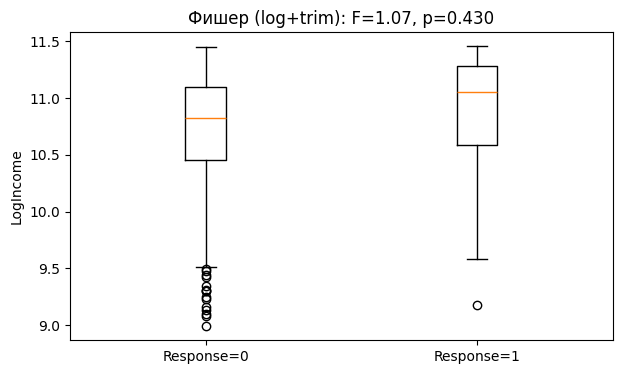

In [ ]:
s0_sq = np.var(g0_prep)
s1_sq = np.var(g1_prep)

if s0_sq >= s1_sq:
    F = s0_sq / s1_sq
    dfn = len(g0_prep) - 1
    dfd = len(g1_prep) - 1
else:
    F = s1_sq / s0_sq
    dfn = len(g1_prep) - 1
    dfd = len(g0_prep) - 1

p_right = 1 - stats.f.cdf(F, dfn, dfd)
p_fisher = 2 * p_right  # двусторонний

print("Фишер:")
print(f"F = {F:.4f}, p = {p_fisher:.4f}")
for alpha in alphas:
    if p_fisher < alpha:
        print(f"α={alpha}: H0 ОТВЕРГАЕТСЯ")
    else:
        print(f"α={alpha}: H0 НЕ отвергается")

plt.figure(figsize=(7, 4))
plt.boxplot([g0_prep, g1_prep], labels=["Response=0", "Response=1"])
plt.title(f"Фишер (log+trim): F={F:.2f}, p={p_fisher:.3f}")
plt.ylabel("LogIncome")
plt.show()

Тест Бартлетта:

Возьмем три самых популяряных семейных статуса.

* H₀: дисперсия в группах равны
* H₁: есть хотя бы одна группа, где дисперсии отличаются

Бартлетт, группы: ['Married', 'Together', 'Single']
stat = 4.942722310128599 p = 0.08446980421383907
α=0.1: H0 ОТВЕРГАЕТСЯ
α=0.05: H0 НЕ отвергается
α=0.01: H0 НЕ отвергается


/tmp/ipython-input-3964990239.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([prep.loc[prep["Marital_Status"] == st, "LogIncome"].values for st in top_statuses_prep], labels=top_statuses_prep)


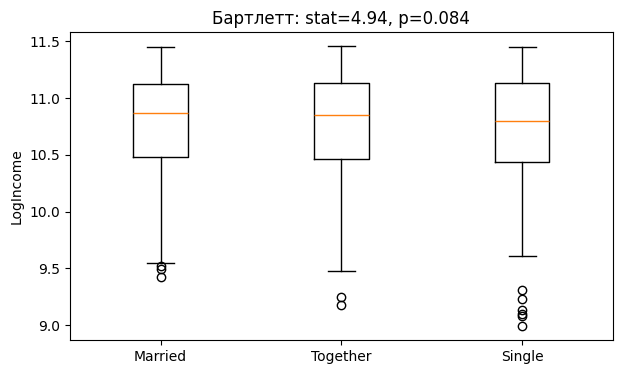

In [ ]:
top_statuses_prep = (prep["Marital_Status"].value_counts().head(3).index.tolist())

groups_prep = [prep.loc[prep["Marital_Status"] == st, "LogIncome"].values for st in top_statuses_prep]

bart_stat, bart_p = stats.bartlett(*groups_prep)
print("Бартлетт, группы:", top_statuses_prep)
print("stat =", bart_stat, "p =", bart_p)
for alpha in alphas:
    if bart_p < alpha:
        print(f"α={alpha}: H0 ОТВЕРГАЕТСЯ")
    else:
        print(f"α={alpha}: H0 НЕ отвергается")

plt.figure(figsize=(7, 4))
plt.boxplot([prep.loc[prep["Marital_Status"] == st, "LogIncome"].values for st in top_statuses_prep], labels=top_statuses_prep)
plt.title(f"Бартлетт: stat={bart_stat:.2f}, p={bart_p:.3f}")
plt.ylabel("LogIncome")
plt.show()

Тест Левене:

Гипотезы те же

Данные используем лог(для нормальности), выбросы обрезаем

Левене, группы: ['Married', 'Together', 'Single']
stat = 1.047571959411364 p = 0.35099576234484114
α=0.1: H0 НЕ отвергается
α=0.05: H0 НЕ отвергается
α=0.01: H0 НЕ отвергается


/tmp/ipython-input-1734069189.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([trim.loc[trim["Marital_Status"] == st, "Income"].values for st in top_statuses_trim], labels=top_statuses_trim)


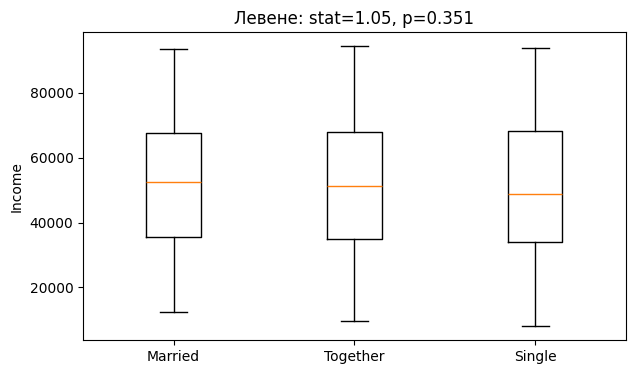

In [ ]:
trim = raw_data.copy()
low_inc, high_inc = np.percentile(trim["Income"], [1, 99])
trim = trim[(trim["Income"] >= low_inc) & (trim["Income"] <= high_inc)]

top_statuses_trim = (trim["Marital_Status"].value_counts().head(3).index.tolist())

groups_trim = [trim.loc[trim["Marital_Status"] == st, "Income"].values for st in top_statuses_trim]

lev_stat, lev_p = stats.levene(*groups_trim)
print("Левене, группы:", top_statuses_trim)
print("stat =", lev_stat, "p =", lev_p)
for alpha in alphas:
    if lev_p < alpha:
        print(f"α={alpha}: H0 ОТВЕРГАЕТСЯ")
    else:
        print(f"α={alpha}: H0 НЕ отвергается")

plt.figure(figsize=(7, 4))
plt.boxplot([trim.loc[trim["Marital_Status"] == st, "Income"].values for st in top_statuses_trim], labels=top_statuses_trim)
plt.title(f"Левене: stat={lev_stat:.2f}, p={lev_p:.3f}")
plt.ylabel("Income")
plt.show()

### 2 Корреляционные взаимосвязи.

Пирсон для линейной связи и примерно нормальных распределений.

Спирмен для нелинейной монотонной связи или выбросов.

Кендалл, когда мало данных или много одинаковых значений.

Выберем числовые столбцы:


In [ ]:
num_cols = df.select_dtypes(include=["number"]).columns.tolist()

manual_drop = ["ID", "Z_CostContact","Z_Revenue", "AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5", "Response", "Complain"]
num_cols = [c for c in num_cols if c not in manual_drop]

#уберём еще столбцы, где слишком мало уникальных значений
clean_cols = []
for c in num_cols:
    if df[c].nunique() > 2:
        clean_cols.append(c)
data_num = df[clean_cols].dropna()
print(clean_cols)

['Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']


In [ ]:
corr_pearson = data_num.corr(method="pearson")
corr_spearman = data_num.corr(method="spearman")
corr_kendall = data_num.corr(method="kendall")

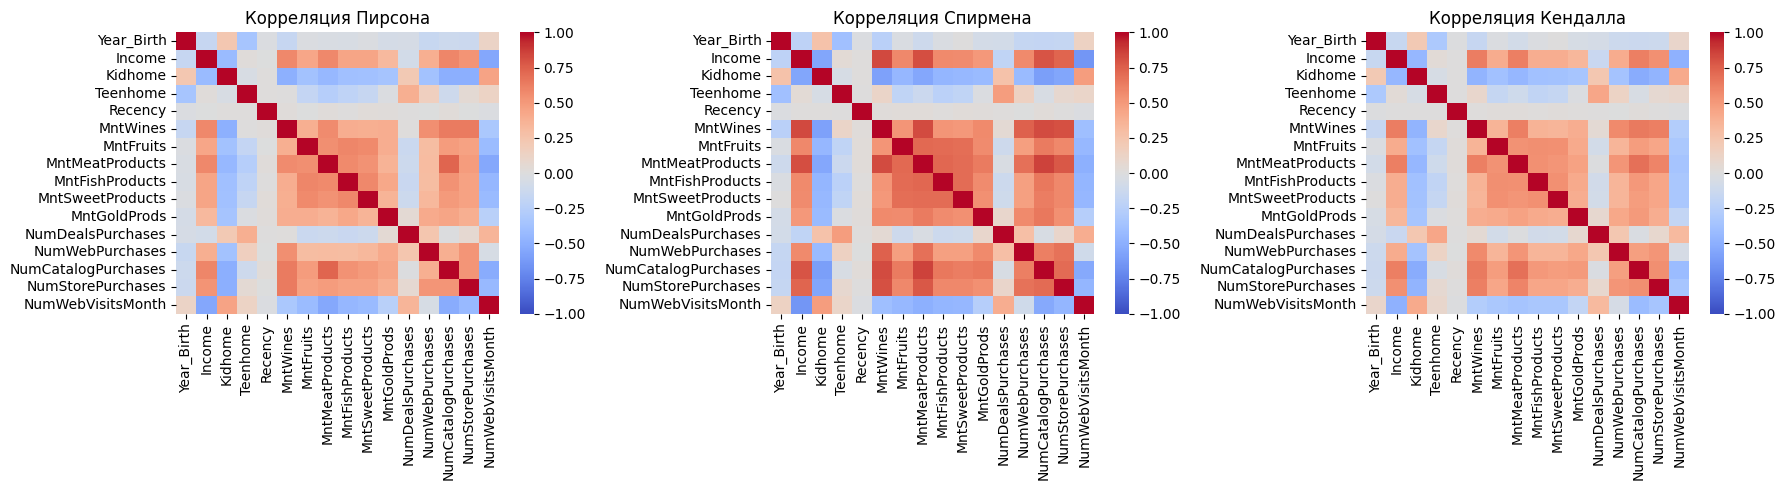

In [ ]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.heatmap(corr_pearson, annot=False, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Корреляция Пирсона")

plt.subplot(1, 3, 2)
sns.heatmap(corr_spearman, annot=False, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Корреляция Спирмена")

plt.subplot(1, 3, 3)
sns.heatmap(corr_kendall, annot=False, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Корреляция Кендалла")

plt.tight_layout()
plt.show()

Посмотрим на пары с самой высокой связью:

In [ ]:
def top_corr_pairs(corr, top_n=10):
    pairs = []
    cols = corr.columns
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            pairs.append((cols[i], cols[j], corr.iloc[i, j]))
    pairs_sorted = sorted(pairs, key=lambda x: abs(x[2]), reverse=True)
    return pairs_sorted[:top_n]

print("Топ 10 пар по Пирсону")
for a, b, c in top_corr_pairs(corr_pearson, 10):
    print(f"{a:22s} — {b:22s}: {c:.3f}")

print("\nТоп 10 пар по Спирмену")
for a, b, c in top_corr_pairs(corr_spearman, 10):
    print(f"{a:22s} — {b:22s}: {c:.3f}")

print("\nТоп 10 пар по Кендаллу")
for a, b, c in top_corr_pairs(corr_kendall, 10):
    print(f"{a:22s} — {b:22s}: {c:.3f}")

Топ 10 пар по Пирсону
MntMeatProducts        — NumCatalogPurchases   : 0.734
MntWines               — NumStorePurchases     : 0.640
MntWines               — NumCatalogPurchases   : 0.635
MntFruits              — MntFishProducts       : 0.593
Income                 — NumCatalogPurchases   : 0.589
Income                 — MntMeatProducts       : 0.585
MntFishProducts        — MntSweetProducts      : 0.584
Income                 — MntWines              : 0.579
MntMeatProducts        — MntFishProducts       : 0.574
MntFruits              — MntSweetProducts      : 0.572

Топ 10 пар по Спирмену
MntMeatProducts        — NumCatalogPurchases   : 0.854
Income                 — MntWines              : 0.830
MntWines               — MntMeatProducts       : 0.824
MntWines               — NumCatalogPurchases   : 0.823
Income                 — MntMeatProducts       : 0.817
MntWines               — NumStorePurchases     : 0.805
Income                 — NumCatalogPurchases   : 0.792
MntMeatProducts    

Клиенты, которые много тратят на вино и мясо (MntWines, MntMeatProducts), чаще покупают через каталог, в магазине и онлайн (NumCatalogPurchases, NumStorePurchases, NumWebPurchases).

Доход связан с тратами. Чем выше Income, тем активнее покупки (особенно вино/мясо).

Категории товаров ведут себя похоже.
Траты на фрукты, рыбу и сладости (MntFruits, MntFishProducts, MntSweetProducts) положительно коррелируют между собой.

Спирмен и Кендалл выше Пирсона. Связь скорее монотонная, а не строго линейная, и ранговые меры устойчивее к выбросам.

###3 Метод хи-квадрат, точный тест Фишера, тест МакНемара, Кохрана-Мантеля-Хензеля.

Хи-квадрат,	когда нужно проверить зависимость между двумя категориальными переменными при достаточно больших выборках.

Точный тест Фишера, когда таблица 2×2 и малое количество наблюдений, проверяет  независимость точно, без приближений.

Тест МакНемара, когда есть парные данные и двоичная переменная, проверяет изменились ли доли.

Тест Кохрана–Мантеля–Хензеля, когда есть несколько таблиц 2×2 для разных слоёв(по какому-то фактору) и нужно проверить общую зависимость, контролируя этот фактор.

Хи-квадрат:

* H0: признак Marital_Status не связан с признаком Response
* H1: признаки зависимы

Таблица сопряжённости Marital_Status x Response
Response          0    1
Marital_Status          
Absurd            1    1
Alone             2    1
Divorced        184   48
Married         766   98
Single          374  106
Together        520   60
Widow            58   19
YOLO              1    1

Хи-квадрат
Хи^2 = 54.242, p = 0.0000
α=0.1: H0 отвергается
α=0.05: H0 отвергается
α=0.01: H0 отвергается


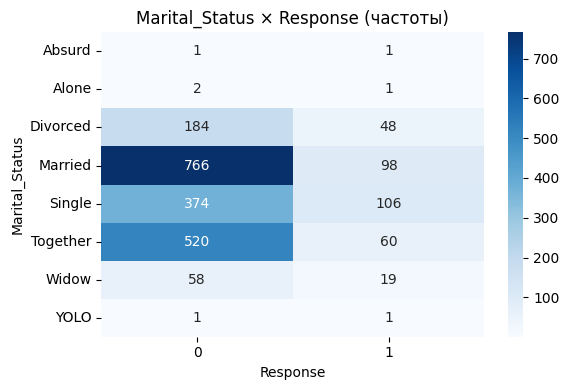

In [ ]:
chi_tab = pd.crosstab(df["Marital_Status"], df["Response"])

print("Таблица сопряжённости Marital_Status x Response")
print(chi_tab)

chi2, p_chi, dof, expected = stats.chi2_contingency(chi_tab)

print("\nХи-квадрат")
print(f"Хи^2 = {chi2:.3f}, p = {p_chi:.4f}")
for alpha in alphas:
    if p_chi < alpha:
        print(f"α={alpha}: H0 отвергается")
    else:
        print(f"α={alpha}: H0 НЕ отвергается")

plt.figure(figsize=(6,4))
sns.heatmap(chi_tab, annot=True, fmt="d", cmap="Blues")
plt.title("Marital_Status × Response (частоты)")
plt.ylabel("Marital_Status")
plt.xlabel("Response")
plt.tight_layout()
plt.show()

Точный тест Фишера:

* H0: признак Complain и Response независимы
* H1: есть связь между Complain и Response


Таблица тест Фишера Complain x Response
Response     0    1
Complain           
0         1888  331
1           18    3

Точный тест Фишера
odds ratio = 0.951, p = 1.0000
α=0.1: H0 НЕ отвергается
α=0.05: H0 НЕ отвергается
α=0.01: H0 НЕ отвергается


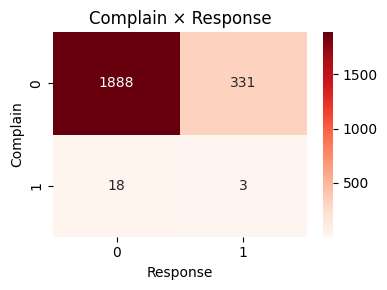

In [ ]:

fisher_tab = pd.crosstab(df["Complain"], df["Response"]).reindex(index=[0,1], columns=[0,1], fill_value=0)

print("Таблица тест Фишера Complain x Response")
print(fisher_tab)

oddsratio, p_fisher = stats.fisher_exact(fisher_tab)

print("\nТочный тест Фишера")
print(f"odds ratio = {oddsratio:.3f}, p = {p_fisher:.4f}")
for alpha in alphas:
    if p_fisher < alpha:
        print(f"α={alpha}: H0 отвергается")
    else:
        print(f"α={alpha}: H0 НЕ отвергается")

plt.figure(figsize=(4,3))
sns.heatmap(fisher_tab, annot=True, fmt="d", cmap="Reds")
plt.title("Complain × Response")
plt.tight_layout()
plt.show()

МакНемер:

Берём два бинарных признака для одной и той же единицы (отклик на кампанию 1 и на кампанию 2). Смотрим, изменилась ли доля "успехов" между ними.

* H0: доля "1" в AcceptedCmp1 = доля "1" в AcceptedCmp2
* H1: доли отличаются

Таблица для МакНемара AcceptedCmp1 и AcceptedCmp2
AcceptedCmp2     0   1
AcceptedCmp1          
0             2079  17
1              131  13

Тест МакНемара
stat = 17.0, p = 0.0000
α=0.1: H0 отвергается
α=0.05: H0 отвергается
α=0.01: H0 отвергается


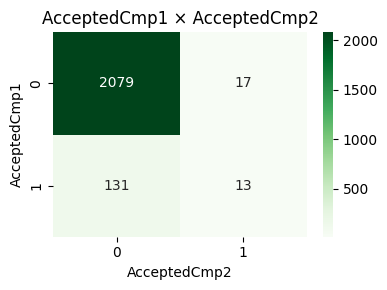

In [ ]:
from statsmodels.stats.contingency_tables import mcnemar
pair = df[["AcceptedCmp1", "AcceptedCmp2"]].dropna()
mcn_tab = pd.crosstab(pair["AcceptedCmp1"], pair["AcceptedCmp2"]).reindex(index=[0,1], columns=[0,1], fill_value=0)

print("Таблица для МакНемара AcceptedCmp1 и AcceptedCmp2")
print(mcn_tab)

mcn_res = mcnemar(mcn_tab, exact=True)
p_mcn = mcn_res.pvalue
print("\nТест МакНемара")
print(f"stat = {mcn_res.statistic}, p = {p_mcn:.4f}")
for alpha in alphas:
    if p_mcn < alpha:
        print(f"α={alpha}: H0 отвергается")
    else:
        print(f"α={alpha}: H0 НЕ отвергается")

plt.figure(figsize=(4,3))
sns.heatmap(mcn_tab, annot=True, fmt="d", cmap="Greens")
plt.title("AcceptedCmp1 × AcceptedCmp2")
plt.tight_layout()
plt.show()

 Кохран-Мантел-Хензел:

Сравниваем два бинарных признака, но с учётом  третьего: связь между Complain (0/1) и Response (0/1), но с учётом количества детей Kidhome (0,1,2).

* H0: при фиксированном значении признака (Kidhome) два бинарных признака независимы
* H1: после учёта Kidhome сохраняется ассоциация между признаками

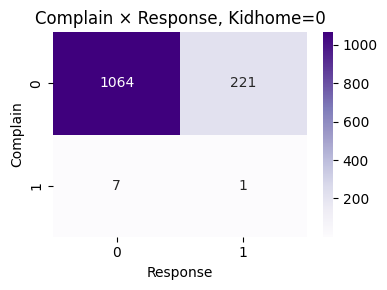

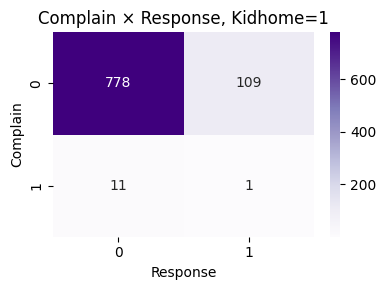

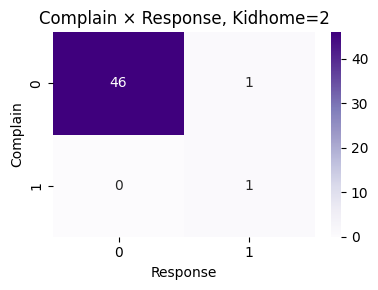

Кохрана–Мантеля–Хензеля

strata (Kidhome): [0, 1, 2]
stat = 0.005551121482122019 p = 0.9406078875592625
α=0.1: H0 НЕ отвергается
α=0.05: H0 НЕ отвергается
α=0.01: H0 НЕ отвергается


In [ ]:
from statsmodels.stats.contingency_tables import StratifiedTable

tables = []
strata_labels = []
for k in [0, 1, 2]:
    sub = df[df["Kidhome"] == k][["Complain", "Response"]]
    if sub.empty:
        continue
    tab = pd.crosstab(sub["Complain"], sub["Response"]).reindex(index=[0,1], columns=[0,1], fill_value=0)
    tables.append(tab.values)
    strata_labels.append(k)

    plt.figure(figsize=(4,3))
    sns.heatmap(tab, annot=True, fmt="d", cmap="Purples")
    plt.title(f"Complain × Response, Kidhome={k}")
    plt.tight_layout()
    plt.show()


st = StratifiedTable(tables)
cmh_res = st.test_null_odds()
p_kmh = cmh_res.pvalue
print("Кохрана–Мантеля–Хензеля")
print("\nstrata (Kidhome):", strata_labels)
print("stat =", cmh_res.statistic, "p =", p_kmh)
for alpha in alphas:
    if p_kmh < alpha:
        print(f"α={alpha}: H0 ОТВЕРГАЕТСЯ")
    else:
        print(f"α={alpha}: H0 НЕ отвергается")


Клиенты, которые жаловались (Complain=1) не откликаются чаще и не реже, чем те, кто не жаловался (Complain=0) и это верно для всех трёх групп: без детей, с одним, и с двумя детьми.

### 4 Мультиколлинеарность в данных.

Ранее мы посмотрели на коэффициенты корреляции Пирсона, Спирмена и Кендалла. Будем использовать коэффициент Спирмена, потому что он устойчивее, а наши данные, скорее всего, связаны монотонно, а не линейно.

Для расчёта фактора инфляции дисперсии подготовим данные, так как распределения сильно скошены и содержат выбросы.

In [ ]:
num_cols = df.select_dtypes(include=["number"]).columns.tolist()

drop_cols = ["ID", "Z_CostContact", "Z_Revenue", "AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5", "Response", "Complain"]
num_cols = [c for c in num_cols if c not in drop_cols]
num_cols = [c for c in num_cols if df[c].nunique() > 2]#только те у кого больше двух уникальных знач

data = df[num_cols].copy()

log_col = ["Income", "MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]
for col in log_col:
    if col in data.columns:
        data[col] = np.log(data[col] + 1)

for col in data.columns:
    low, high = data[col].quantile([0.01, 0.99])
    data[col] = data[col].clip(lower=low, upper=high)

data = data.dropna().reset_index(drop=True)

print("Признаки после подготовки:")
print(list(data.columns))

Признаки после подготовки:
['Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']


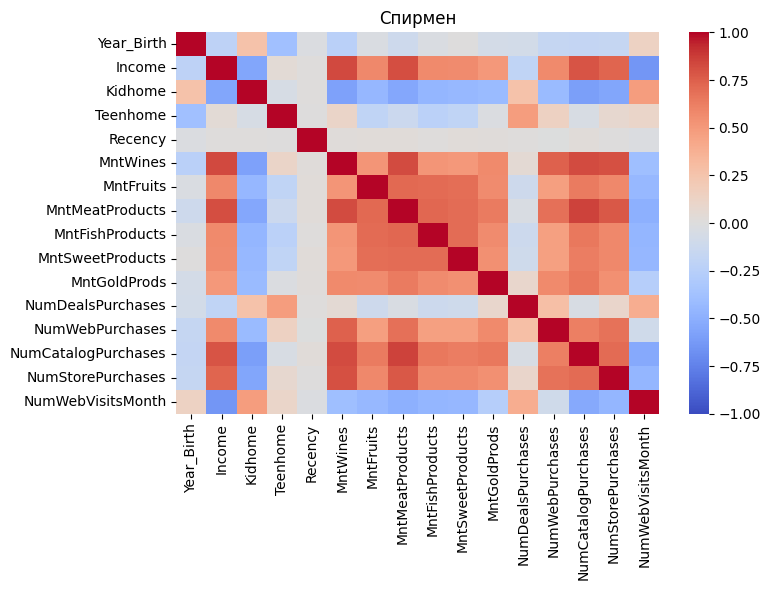

In [ ]:
corr_spearman = data.corr(method="spearman")

plt.figure(figsize=(8, 6))
sns.heatmap(corr_spearman, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Спирмен")
plt.tight_layout()
plt.show()

In [ ]:
X = data.copy()
X = sm.add_constant(X)#добавляет в матрицу признаков столбец из единиц, чтобы линейна регр внутри variance_inflation_factor корректно работала(свободный член)

vif_rows = []
for i, col in enumerate(X.columns):
    if col == "const":
        continue
    vif_val = variance_inflation_factor(X.values, i)
    vif_rows.append((col, vif_val))

vif_df = pd.DataFrame(vif_rows, columns=["feature", "VIF"]).sort_values("VIF", ascending=False)
print("Фактора инфляции дисперсии:")
print(vif_df)

Фактора инфляции дисперсии:
                feature       VIF
7       MntMeatProducts  7.823141
5              MntWines  7.798872
1                Income  4.429715
13  NumCatalogPurchases  2.885394
8       MntFishProducts  2.736421
12      NumWebPurchases  2.728220
6             MntFruits  2.711071
15    NumWebVisitsMonth  2.639349
9      MntSweetProducts  2.593066
14    NumStorePurchases  2.563812
2               Kidhome  2.068401
10         MntGoldProds  1.914527
11    NumDealsPurchases  1.874833
3              Teenhome  1.847747
0            Year_Birth  1.264676
4               Recency  1.005791


###5 Дисперсионный анализ.

Этот тест чувствелен к выбросам и требует около нормальных данных.

* H0: средний LogIncome одинаков для всех категорий Marital_Status
* H1: хотя бы в одной группе средний LogIncome отличается

* H0: средний LogIncome одинаков для всех уровней образования
* H1: доход отличается хотя бы в одной группе образования

Размер данных: (2170, 4)


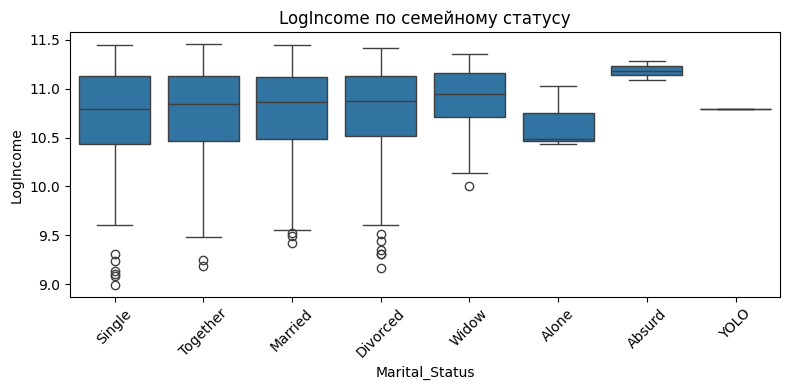

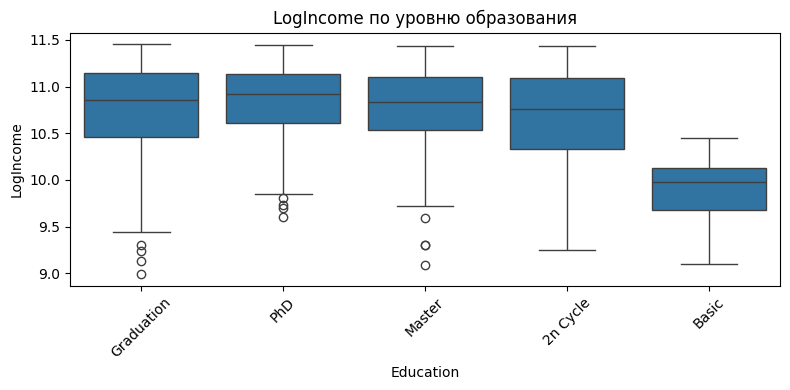

LogIncome ~ Marital_Status
                       sum_sq      df         F    PR(>F)
C(Marital_Status)    2.178801     7.0  1.547534  0.146749
Residual           434.845688  2162.0       NaN       NaN

LogIncome ~ Education
                  sum_sq      df          F        PR(>F)
C(Education)   45.827633     4.0  63.405945  9.535232e-51
Residual      391.196856  2165.0        NaN           NaN

LogIncome ~ Education + Marital_Status
                       sum_sq      df          F        PR(>F)
C(Education)        45.118303     4.0  62.457312  5.251590e-50
C(Marital_Status)    1.469472     7.0   1.162395  3.211961e-01
Residual           389.727385  2158.0        NaN           NaN


In [ ]:
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

data = df[["Income", "Marital_Status", "Education"]].dropna()

data["LogIncome"] = np.log(data["Income"] + 1)

low, high = np.percentile(data["LogIncome"], [1, 99])
data = data[(data["LogIncome"] >= low) & (data["LogIncome"] <= high)]

print("Размер данных:", data.shape)

plt.figure(figsize=(8, 4))
sns.boxplot(data=data, x="Marital_Status", y="LogIncome")
plt.title("LogIncome по семейному статусу")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(data=data, x="Education", y="LogIncome")
plt.title("LogIncome по уровню образования")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

model_ms = ols("LogIncome ~ C(Marital_Status)", data=data).fit()#линейная регрессия
anova_ms = anova_lm(model_ms, typ=2)
print("LogIncome ~ Marital_Status")
print(anova_ms)

print()

model_ed = ols("LogIncome ~ C(Education)", data=data).fit()
anova_ed = anova_lm(model_ed, typ=2)
print("LogIncome ~ Education")
print(anova_ed)

print()

model_2way = ols("LogIncome ~ C(Education) + C(Marital_Status)", data=data).fit()
anova_2way = anova_lm(model_2way, typ=2)
print("LogIncome ~ Education + Marital_Status")
print(anova_2way)

Доход (в логарифмах) сильно зависит от образования, но не зависит от семейного положения.

При добавлении обоих факторов в модель значим остаётся только уровень образования.

### 6 Регрессионные модели (в том числе нелинейные)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [ ]:
num_cols = df.select_dtypes(include=["number"]).columns.tolist()

drop_cols = ["ID", "Z_CostContact", "Z_Revenue", "AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5", "Response", "Complain"]
num_cols = [c for c in num_cols if c not in drop_cols]

if "Income" in num_cols:
    num_cols.remove("Income")

X = df[num_cols].copy()
y = df["Income"].copy()

data = pd.concat([X, y], axis=1).dropna().reset_index(drop=True)
X = data[num_cols].copy()
y = data["Income"].copy()

y = np.log(y + 1)

low, high = np.percentile(y, [1, 99])
mask = (y >= low) & (y <= high)

X = X.loc[mask].reset_index(drop=True)
y = y.loc[mask].reset_index(drop=True)

print("Размер после подготовки:", X.shape, y.shape)
print("Признаки модели:", num_cols)


Размер после подготовки: (2170, 15) (2170,)
Признаки модели: ['Year_Birth', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=12)

In [ ]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred_lin = lin_reg.predict(X_test)

r2_lin = r2_score(y_test, y_pred_lin)
mae_lin = mean_absolute_error(y_test, y_pred_lin)
rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))

print("Линейная регрессия:")
print("R^2 :", round(r2_lin, 3))
print("MAE :", round(mae_lin, 3))
print("RMSE:", round(rmse_lin, 3))

Линейная регрессия:
R^2 : 0.73
MAE : 0.173
RMSE: 0.237


In [ ]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

lin_reg_poly = LinearRegression()
lin_reg_poly.fit(X_train_poly, y_train)

y_pred_poly = lin_reg_poly.predict(X_test_poly)

r2_poly = r2_score(y_test, y_pred_poly)
mae_poly = mean_absolute_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))

print("Полиномиальная регрессия:")
print("R^2 :", round(r2_poly, 3))
print("MAE :", round(mae_poly, 3))
print("RMSE:", round(rmse_poly, 3))

Полиномиальная регрессия:
R^2 : 0.81
MAE : 0.143
RMSE: 0.199


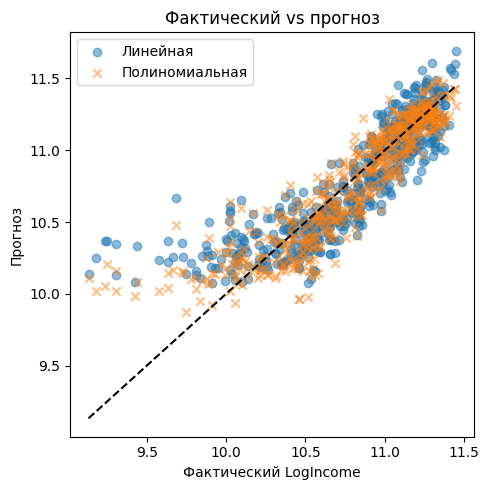

In [ ]:
plt.figure(figsize=(5, 5))
plt.scatter(y_test, y_pred_lin, alpha=0.5, label="Линейная")
plt.scatter(y_test, y_pred_poly, alpha=0.5, label="Полиномиальная", marker="x")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--")
plt.xlabel("Фактический LogIncome")
plt.ylabel("Прогноз")
plt.title("Фактический vs прогноз")
plt.legend()
plt.tight_layout()
plt.show()

Обучили линейную и полиномиальную (степень 2) регрессию для прогнозирования LogIncome. Линейная модель объясняет около 73% значений целевой переменной. Добавление квадратичных признаков улучшает качество: R^2 увеличивается до 0.81. На графике полиномиальная модель даёт точки более плотно лежащие вдоль диагонали. Таким образом, слабая нелинейность между признаками и LogIncome действительно присутствует, и полиномиальная регрессия описывает данные лучше, чем простая линейная.